In [82]:
%pip install librosa
%pip install scipy
%pip install ffmpeg
%pip install mediapipe
%pip install decord --upgrade
%pip install spikingjelly


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [83]:
import numpy as np
import scipy
import scipy.signal
import torch
import librosa
import matplotlib.pyplot as plt
import torch.nn as nn
from torch import Tensor
from collections.abc import Sequence
from functools import partial
from spikingjelly.activation_based import neuron, surrogate
from spikingjelly.activation_based import functional
from typing import Any, Callable, Optional, Union
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from mediapipe.tasks.python.vision import drawing_utils
from mediapipe.tasks.python.vision import drawing_styles
import numpy as np
import matplotlib.pyplot as plt
import mediapipe as mp
from tqdm.notebook import tqdm
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import cv2
from decord import VideoReader, cpu


# Step 1: Visual - Frontend Processing

## 1. Chuyển từ 30fps sang 25fps


In [9]:
# !ffmpeg -i "Dataset_Output\_Địa chấn_ lao động toàn cầu： Người trẻ buông chuột để làm lao động chân tay _ VTV24\00016\video.mp4" -r 25 -s 1920x1080 -vcodec libx264 -pix_fmt yuv420p -crf 23 -preset fast "Speech Reconstruction/tester.mp4" -y

## 2. Chuyển từ 48khz sang 16khz


In [10]:
# !ffmpeg -hide_banner -loglevel error -y -i "Speech Reconstruction\tester.mp4" -c:v copy -acodec aac -ar 16000 -ac 1 "Speech Reconstruction\tester16khz.mp4"


## 3. Trích xuất Mouth ROI bằng Frame Landmaker

In [11]:
!curl -o face_landmarker_v2_with_blendshapes.task https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
 13  3.58M  13 486.0k   0      0 468.8k      0   00:07   00:01   00:06 469.5k
 44  3.58M  44  1.61M   0      0 788.3k      0   00:04   00:02   00:02 788.9k
 66  3.58M  66  2.37M   0      0 751.3k      0   00:04   00:03   00:01 751.7k
 85  3.58M  85  3.07M   0      0 743.7k      0   00:04   00:04         744.0k
100  3.58M 100  3.58M   0      0 746.4k      0   00:04   00:04         744.0k
100  3.58M 100  3.58M   0      0 746.4k      0   00:04   00:04         744.0k
100  3.58M 100  3.58M   0      0 746.3k      0   00:04   00:04         744.0k


### Face Mesh and npz

In [12]:
# def draw_landmarks_on_image(rgb_image, detection_result):
#   face_landmarks_list = detection_result.face_landmarks
#   annotated_image = np.copy(rgb_image)

#   # Loop through the detected faces to visualize.
#   for idx in range(len(face_landmarks_list)):
#     face_landmarks = face_landmarks_list[idx]

#     # Draw the face landmarks.


#     drawing_utils.draw_landmarks(
#         image=annotated_image,
#         landmark_list=face_landmarks,
#         connections=vision.FaceLandmarksConnections.FACE_LANDMARKS_TESSELATION,
#         landmark_drawing_spec=None,
#         connection_drawing_spec=drawing_styles.get_default_face_mesh_tesselation_style())
#     drawing_utils.draw_landmarks(
#         image=annotated_image,
#         landmark_list=face_landmarks,
#         connections=vision.FaceLandmarksConnections.FACE_LANDMARKS_CONTOURS,
#         landmark_drawing_spec=None,
#         connection_drawing_spec=drawing_styles.get_default_face_mesh_contours_style())
#     drawing_utils.draw_landmarks(
#         image=annotated_image,
#         landmark_list=face_landmarks,
#         connections=vision.FaceLandmarksConnections.FACE_LANDMARKS_LEFT_IRIS,
#           landmark_drawing_spec=None,
#           connection_drawing_spec=drawing_styles.get_default_face_mesh_iris_connections_style())
#     drawing_utils.draw_landmarks(
#         image=annotated_image,
#         landmark_list=face_landmarks,
#         connections=vision.FaceLandmarksConnections.FACE_LANDMARKS_RIGHT_IRIS,
#           landmark_drawing_spec=None,
#           connection_drawing_spec=drawing_styles.get_default_face_mesh_iris_connections_style())

#   return annotated_image

# def plot_face_blendshapes_bar_graph(face_blendshapes):
#   # Extract the face blendshapes category names and scores.
#   face_blendshapes_names = [face_blendshapes_category.category_name for face_blendshapes_category in face_blendshapes]
#   face_blendshapes_scores = [face_blendshapes_category.score for face_blendshapes_category in face_blendshapes]
#   # The blendshapes are ordered in decreasing score value.
#   face_blendshapes_ranks = range(len(face_blendshapes_names))

#   fig, ax = plt.subplots(figsize=(12, 12))
#   bar = ax.barh(face_blendshapes_ranks, face_blendshapes_scores, label=[str(x) for x in face_blendshapes_ranks])
#   ax.set_yticks(face_blendshapes_ranks, face_blendshapes_names)
#   ax.invert_yaxis()

#   # Label each bar with values
#   for score, patch in zip(face_blendshapes_scores, bar.patches):
#     plt.text(patch.get_x() + patch.get_width(), patch.get_y(), f"{score:.4f}", va="top")

#   ax.set_xlabel('Score')
#   ax.set_title("Face Blendshapes")
#   plt.tight_layout()
#   plt.show()

In [13]:
# # STEP 2: Cấu hình FaceLandmarker
# base_options = python.BaseOptions(model_asset_path='face_landmarker_v2_with_blendshapes.task')
# options = vision.FaceLandmarkerOptions(
#     base_options=base_options,
#     output_face_blendshapes=True,
#     output_facial_transformation_matrixes=True,
#     running_mode=vision.RunningMode.VIDEO, # Chế độ tối ưu cho video
#     num_faces=1)

# # Khởi tạo VideoReader
# video_path = "Speech Reconstruction/tester16khz.mp4"
# vr = VideoReader(video_path, ctx=cpu(0))
# fps = 25

# # Setup VideoWriter để vẽ thử kết quả (Bước 2.3)
# w, h = int(vr[0].shape[1]), int(vr[0].shape[0])
# out = cv2.VideoWriter('Speech Reconstruction/tester16khz_landmakers.mp4',
#                          cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))

# all_results = []

# # Dùng context manager để tự động giải phóng detector
# with vision.FaceLandmarker.create_from_options(options) as detector:
#     for i in range(len(vr)):
#         frame = vr[i].asnumpy() # Decord trả về RGB

#         # Chuyển sang định dạng mp.Image
#         mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame)

#         # Tính toán timestamp (ms) - 25fps ứng với 40ms/frame
#         frame_timestamp_ms = int(i * (1000 / fps))

#         # Dùng detect_for_video
#         result = detector.detect_for_video(mp_image, frame_timestamp_ms)
#         all_results.append(result)

#         annotated_frame = draw_landmarks_on_image(frame, result)
#         out.write(cv2.cvtColor(annotated_frame, cv2.COLOR_RGB2BGR))

# out.release()
# print(f"{len(all_results)} frames!")

### Save landmaker to npz

In [14]:
# import numpy as np

# def save_landmarks_to_npz(all_results, output_path, source_name):
#     all_landmarks = []
#     all_blendshapes = []

#     for result in all_results:
#         if result and result.face_landmarks:
#             # Lấy 468 điểm (x, y, z)
#             current_frame = [[lm.x, lm.y, lm.z] for lm in result.face_landmarks[0]]
#             all_landmarks.append(current_frame)

#             # Lấy 52 chỉ số Blendshapes
#             if result.face_blendshapes:
#                 scores = [b.score for b in result.face_blendshapes[0]]
#                 all_blendshapes.append(scores)
#             else:
#                 all_blendshapes.append(np.zeros(52))
#         else:
#             # Frame lỗi hoặc không thấy mặt
#             all_landmarks.append(np.zeros((468, 3)))
#             all_blendshapes.append(np.zeros(52))

#     # Chuyển thành mảng NumPy
#     all_landmarks_np = np.array(all_landmarks)
#     all_blendshapes_np = np.array(all_blendshapes)

#     # Lưu file nén
#     np.savez_compressed(
#         output_path,
#         landmarks=all_landmarks_np,
#         blendshapes=all_blendshapes_np,
#         metadata={'fps': 25, 'source': source_name}
#     )
#     print(f"{len(all_landmarks_np)} frames vào {output_path}")

In [15]:
# save_landmarks_to_npz(all_results, 'Speech Reconstruction/tester16khz_Full_Data.npz', 'Speech Reconstruction/tester16khz.mp4')

### Affine transform


In [16]:
def affine_trans(landmarks, frame, target_size=(224, 224)):
  h, w, _ = frame.shape
  left = np.array([landmarks[33][0] * w, landmarks[33][1] * h])
  right = np.array([landmarks[263][0] * w, landmarks[263][1] * h])

  dY = right[1] - left[1]
  dX = right[0] - left[0]

  angle = np.degrees(np.arctan2(dY, dX))

  theta = ((left[0] + right[0]) / 2, (left[1] + right[1]) / 2)

  distance = np.sqrt((left[0] - right[0])**2 + (left[1] - right[1])**2)
  ratio = target_size[0] * 0.3
  scale = ratio / distance

  Matrix = cv2.getRotationMatrix2D(theta, angle, scale)
  Matrix[0, 2] += (target_size[0] * 0.5) - theta[0]
  Matrix[1, 2] += (target_size[1] * 0.35) - theta[1]

  transform = cv2.warpAffine(frame, Matrix, target_size, flags=cv2.INTER_CUBIC)

  return transform

### Đọc file npz landmaker và áp dụng Affine

In [17]:
# def read_timestamp(video_path, landmark_path):
#   data = np.load(landmark_path, allow_pickle=True)
#   landmarks = data['landmarks']
#   vr = VideoReader(video_path, ctx=cpu(0))
#   out = cv2.VideoWriter('Speech Reconstruction/tester16khz_aff.mp4', cv2.VideoWriter_fourcc(*'mp4v'), 25, (224, 224))
#   for i in range(len(vr)):
#     frame = vr[i].asnumpy()
#     landmark = landmarks[i]

#     if landmark is not None:
#       transform = affine_trans(landmark, frame)
#       out.write(cv2.cvtColor(transform, cv2.COLOR_RGB2BGR))
#     else:
#       out.write(np.zeros((h, w, 3), dtype=np.uint8))
#   out.release()


In [18]:
# read_timestamp('Speech Reconstruction/tester16khz.mp4', 'Speech Reconstruction/tester16khz_Full_Data.npz')

### Trích xuất môi


In [19]:
def lips(transform, landmark_path, size=112):
      data = np.load(landmark_path, allow_pickle=True)
      landmarks = data['landmarks']
      midX = (landmarks[61][0] + landmarks[291][0]) / 2
      midY = (landmarks[0][1] + landmarks[17][1]) / 2

      half = size // 2
      
      y1, y2 = max(0, int(midY - half)), int(midY + half)
      x1, x2 = max(0, int(midX - half)), int(midX + half)
      
      lip_roi = transform[y1:y2, x1:x2]

      # Nếu cắt bị thiếu do chạm biên, resize lại cho đủ 112x112
      if lip_roi.shape[0] != size or lip_roi.shape[1] != size:
            lip_roi = cv2.resize(lip_roi, (size, size))
      
      # if len(lip_roi.shape) == 3:
      #       lip_roi = cv2.cvtColor(lip_roi, cv2.COLOR_BGR2GRAY)

      return lip_roi

## 4. ĐỒNG BỘ STFT -> Mel-Spectrogram

In [20]:
# # def get_aligned_mel(audio_path,  num_video_frames, sr=16000, n_mels=80):
# #     y, _ = librosa.load(audio_path, sr=sr)

# #     hop_length = int(sr / fps)
# #     n_fft = 1024

# #     mel_spec = librosa.feature.melspectrogram(
# #         y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels
# #     )

# #     log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
# #     T_audio = log_mel_spec.shape[1]

# #     if T_audio > num_video_frames:
# #         log_mel_spec = log_mel_spec[:, :num_video_frames]
# #     elif T_audio < num_video_frames:
# #         padding = num_video_frames - T_audio
# #         last_frame = log_mel_spec[:, -1:]
# #         pad_matrix = np.repeat(last_frame, padding, axis=1)
# #         log_mel_spec = np.concatenate([log_mel_spec, pad_matrix], axis=1)
    
# #     assert log_mel_spec.shape[1] == num_video_frames, "Số khung hình âm thanh không khớp với số khung hình video sau khi căn chỉnh."
# #     return log_mel_spec



# # def get_aligned_mel(audio_path, fps, num_video_frames, sr=16000, n_mels=80):
# #     y, _ = librosa.load(audio_path, sr=sr)  # vẫn load bằng librosa
# #     y_tensor = torch.from_numpy(y).float().unsqueeze(0)  # (1, T)

# #     mel_spec, _ = mel_spectogram(
# #         audio=y_tensor,
# #         sample_rate=sr,
# #         hop_length=int(sr / fps),
# #         win_length=1024,
# #         n_fft=1024,
# #         n_mels=n_mels,
# #         f_min=0.0,
# #         f_max=8000.0,
# #         power=1,
# #         normalized=False,
# #         min_max_energy_norm=True,
# #         norm="slaney",
# #         mel_scale="slaney",
# #         compression=True
# #     )
# #     mel_spec = mel_spec.squeeze(0).cpu().numpy()  # (n_mels, T)
# #     # cắt/pad để đồng bộ với video
# #     T_audio = mel_spec.shape[1]
# #     if T_audio > num_video_frames:
# #         mel_spec = mel_spec[:, :num_video_frames]
# #     elif T_audio < num_video_frames:
# #         padding = num_video_frames - T_audio
# #         pad_matrix = np.repeat(mel_spec[:, -1:], padding, axis=1)
# #         mel_spec = np.concatenate([mel_spec, pad_matrix], axis=1)
# #     return mel_spec


# def get_aligned_mel(audio_path, fps, num_video_frames, sr=16000, n_mels=80):
#     """Chuyển audio -> mel spectrogram bằng librosa, config khớp speechbrain."""
#     y, _ = librosa.load(audio_path, sr=sr)
    
#     hop_length = 256
    
#     # STFT -> Mel (power=1 => dùng magnitude, không phải power)
#     mel_spec = librosa.feature.melspectrogram(
#         y=y,
#         sr=sr,
#         n_fft=1024,
#         hop_length=hop_length,
#         win_length=1024,
#         n_mels=n_mels,
#         fmin=0.0,
#         fmax=8000.0,
#         power=1,              # magnitude spectrogram (khớp speechbrain power=1)
#         norm="slaney",         # khớp norm="slaney"
#         htk=False,             # htk=False = mel_scale="slaney"
#     )
    
#     # compression=True trong speechbrain = log1p
#     mel_spec = np.log1p(mel_spec)
    
#     # min_max_energy_norm=True trong speechbrain = normalize về [0, 1]
#     # mel_min = mel_spec.min()
#     # mel_max = mel_spec.max()
#     # if mel_max - mel_min > 1e-8:
#     #     mel_spec = (mel_spec - mel_min) / (mel_max - mel_min)
    
#     # Cắt/pad để đồng bộ với video
#     T_audio = mel_spec.shape[1]
#     if T_audio > num_video_frames:
#         mel_spec = mel_spec[:, :num_video_frames]
#     elif T_audio < num_video_frames:
#         padding = num_video_frames - T_audio
#         pad_matrix = np.repeat(mel_spec[:, -1:], padding, axis=1)
#         mel_spec = np.concatenate([mel_spec, pad_matrix], axis=1)
    
#     return mel_spec  # shape: (n_mels, T)


# STEP 2. SPIKING VISUAL ENCODER

## Direct Encoding

In [84]:

class SpikingDirectEncoder(nn.Sequential):
    def __init__(self, in_channels=1, out_channels=64) -> None:
        super().__init__()
        self.spatial_conv = nn.Conv3d(in_channels, 45, kernel_size=(1, 7, 7), stride=(1, 2, 2), padding=(0, 3, 3), bias=False)
        self.bn1 = nn.BatchNorm3d(45)
        self.lif1 = neuron.LIFNode(tau=2.0, surrogate_function=surrogate.ATan())

        self.temporal_conv = nn.Conv3d(45, out_channels, kernel_size=(5, 1, 1), stride=(1, 1, 1), padding=(2, 0, 0), bias=False)
        self.bn2 = nn.BatchNorm3d(out_channels)
        self.lif2 = neuron.LIFNode(tau=2.0, surrogate_function=surrogate.ATan())

    def forward(self, X):
        # X: (B, C, T, H, W)
        s1 = self.spatial_conv(X)
        b1 = self.bn1(s1)
        l1 = self.lif1(b1)

        s2 = self.temporal_conv(l1)
        b2 = self.bn2(s2)
        l2 = self.lif2(b2)
        return l2

## ResNet 2D Plus 1D feature extraction

In [85]:
class SpikingConv2DPlus1D(nn.Sequential):
    def __init__(self, in_channels: int, out_channels: int, mid_channels: int, stride: int=1, padding: int=1):
        super().__init__(
          nn.Conv3d(
              in_channels=in_channels,
              out_channels=mid_channels,
              kernel_size=(1, 3, 3),
              stride=(1, stride, stride),
              padding=(0, padding, padding),
              bias=False,
          ),
          nn.BatchNorm3d(mid_channels),
          neuron.LIFNode(surrogate_function=surrogate.ATan()),
          nn.Conv3d(
              in_channels=mid_channels,
              out_channels=out_channels,
              kernel_size=(3, 1, 1),
              stride=(1, 1, 1),
              padding=(1, 0, 0),
              bias=False,
          ),
        )
    @staticmethod
    def get_stride(stride: int):
        return stride, stride, stride



In [86]:
class SpikingBasicBlock(nn.Module):
    expansion: int = 1
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        conv_builder: Callable[..., nn.Module],
        stride: int = 1,
        downsample: Optional[nn.Module] = None,
    ) -> None:
        mid_channels = (in_channels * out_channels * 3 * 3 * 3) // (in_channels * out_channels * 1 * 3 * 3 + in_channels * out_channels * 3 * 1 * 1)
        super().__init__()
        self.conv1 = nn.Sequential(
            conv_builder(in_channels, out_channels, mid_channels, stride),
            nn.BatchNorm3d(out_channels),
            neuron.LIFNode(tau=2.0, surrogate_function=surrogate.ATan())
        )
        self.conv2 = nn.Sequential(
            conv_builder(out_channels, out_channels, mid_channels),
            nn.BatchNorm3d(out_channels),
        )
        self.lif = neuron.LIFNode(tau=2.0, surrogate_function=surrogate.ATan())
        self.downsample = downsample
        self.stride = stride

    def forward(self, X: Tensor) -> Tensor:
        residual = X
        out = self.conv1(X)
        out = self.conv2(out)
        if self.downsample is not None:
            residual = self.downsample(X)
        out += residual
        out = self.lif(out)
        return out


In [87]:
from torch.utils.checkpoint import checkpoint
from spikingjelly.activation_based import functional

class VidResNet(nn.Module):
    def __init__(
        self,
        block = SpikingBasicBlock,
        conv_makers = [SpikingConv2DPlus1D] * 4,
        layers = [2, 2, 2, 2],
        zero_init_residual: bool = False,
    ):
        super().__init__()
        self.in_channels = 64
        self.stem = SpikingDirectEncoder(in_channels=1, out_channels=64)

        self.layer1 = self._make_layer(block, 64, conv_makers[0], layers[0], stride=1)
        self.layer2 = self._make_layer(block, 128, conv_makers[1], layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, conv_makers[2], layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, conv_makers[3], layers[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool3d((None, 1, 1))
        self.fc = nn.Linear(512 * block.expansion, 512)

        for m in self.modules():
            if isinstance(m, nn.Conv3d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm3d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

        if zero_init_residual:
            for m in self.modules():
                if isinstance(m, SpikingBasicBlock):
                    nn.init.constant_(m.bn3.weight, 0)

    # ★ Helper: checkpoint an toàn cho SNN
    def _snn_checkpoint(self, layer, X):
        """Gradient checkpointing có reset neuron states."""
        def _forward(x):
            functional.reset_net(layer)  # Reset v, spike của LIF/PLIF trong layer
            return layer(x)
        return checkpoint(_forward, X, use_reentrant=True)

    def forward(self, X: Tensor) -> Tensor:
        X = self.stem(X)
        # ★ Checkpoint từng block, không phải từng layer
        for block in self.layer1:
            X = self._snn_checkpoint(block, X)
        for block in self.layer2:
            X = self._snn_checkpoint(block, X)
        for block in self.layer3:
            X = self._snn_checkpoint(block, X)
        for block in self.layer4:
            X = self._snn_checkpoint(block, X)
        X = self.avgpool(X)
        X = X.squeeze(-1).squeeze(-1)
        X = X.permute(0, 2, 1)
        X = self.fc(X)
        return X

    def _make_layer(
        self,
        block: SpikingBasicBlock,
        out_channels: int,
        conv_builder: Callable[..., nn.Module],
        num_blocks: int,
        stride: int,
    ) -> nn.Sequential:
        downsample = None

        if stride != 1 or self.in_channels != out_channels * block.expansion:
            downsample = nn.Sequential(
                nn.Conv3d(self.in_channels, out_channels * block.expansion, kernel_size=1, stride=(1, stride, stride), bias=False),
                nn.BatchNorm3d(out_channels * block.expansion)
            )
        layers = []
        layers.append(block(self.in_channels, out_channels, conv_builder, stride, downsample))

        self.in_channels = out_channels * block.expansion
        for i in range(1, num_blocks):
            layers.append(block(self.in_channels, out_channels, conv_builder))

        return nn.Sequential(*layers)


## Spiking Transformer (S - ViT)

## Attention

In [88]:
class SpikingAttention(nn.Module):
    def __init__(self, z_dim=512, n_heads=8):
        super().__init__()
        self.n_heads = n_heads
        self.dim_head = z_dim // n_heads
        self.scale = self.dim_head ** -0.5

        self.q_linear = nn.Linear(z_dim, z_dim)
        self.k_linear = nn.Linear(z_dim, z_dim)
        self.v_linear = nn.Linear(z_dim, z_dim)

        self.q_plif = neuron.ParametricLIFNode(init_tau=2.0, surrogate_function=surrogate.ATan())
        self.k_plif = neuron.ParametricLIFNode(init_tau=2.0, surrogate_function=surrogate.ATan())
        self.v_plif = neuron.ParametricLIFNode(init_tau=2.0, surrogate_function=surrogate.ATan())

        self.attn_plif = neuron.ParametricLIFNode(init_tau=2.0, surrogate_function=surrogate.ATan())
        self.proj = nn.Linear(z_dim, z_dim)

    def forward(self, X):
        B, T, C = X.shape

        # Q, K, V
        q = self.q_linear(X)                # (B, T, C)
        k = self.k_linear(X)
        v = self.v_linear(X)

        # Đưa qua PLIF (flatten theo thời gian)
        q = q.reshape(B * T, C)
        q = self.q_plif(q)
        q = q.reshape(B, T, C)

        k = k.reshape(B * T, C)
        k = self.k_plif(k)
        k = k.reshape(B, T, C)

        v = v.reshape(B * T, C)
        v = self.v_plif(v)
        v = v.reshape(B, T, C)

        # Multi-head reshape
        q = q.reshape(B, T, self.n_heads, self.dim_head).permute(0, 2, 1, 3)  # (B, n_heads, T, dim_head)
        k = k.reshape(B, T, self.n_heads, self.dim_head).permute(0, 2, 1, 3)
        v = v.reshape(B, T, self.n_heads, self.dim_head).permute(0, 2, 1, 3)

        # Attention scores
        attn_scores = (q @ k.transpose(-2, -1)) * self.scale   # (B, n_heads, T, T)
        attn_out = attn_scores @ v                             # (B, n_heads, T, dim_head)

        # Merge heads
        attn_out = attn_out.permute(0, 2, 1, 3).reshape(B, T, C)  # (B, T, C)

        # attn_plif
        attn_out = attn_out.reshape(B * T, C)
        attn_out = self.attn_plif(attn_out)
        attn_out = attn_out.reshape(B, T, C)

        # Projection
        out = self.proj(attn_out)          # (B, T, C)
        return out

## MLP

In [89]:
class SpikingMLP(nn.Module):
    def __init__(self, in_dim=512, hidden_dim=2048, out_dim=512):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)

        self.plif = neuron.ParametricLIFNode(init_tau=2.0, surrogate_function=surrogate.ATan())
        
        self.fc2 = nn.Linear(hidden_dim, out_dim)
        self.bn2 = nn.BatchNorm1d(out_dim)

    def forward(self, X):
        # X: (B, T, C)
        B, T, C = X.shape

        # fc1
        X = self.fc1(X)                     # (B, T, hidden_dim)
        # Chuẩn bị cho BN1 (yêu cầu (N, C, L) với L=1)
        X = X.reshape(B * T, -1)            # (B*T, hidden_dim)
        X = X.unsqueeze(-1)                 # (B*T, hidden_dim, 1)
        X = self.bn1(X)                     # BN trên kênh hidden_dim
        X = X.squeeze(-1)                   # (B*T, hidden_dim)

        # Neuron PLIF (xử lý từng vector độc lập)
        X = self.plif(X)                    # (B*T, hidden_dim)
        X = X.reshape(B, T, -1)             # (B, T, hidden_dim)

        # fc2
        X = self.fc2(X)                     # (B, T, out_dim)
        # BN2
        X = X.reshape(B * T, -1)            # (B*T, out_dim)
        X = X.unsqueeze(-1)                 # (B*T, out_dim, 1)
        X = self.bn2(X)
        X = X.squeeze(-1)                   # (B*T, out_dim)
        X = X.reshape(B, T, -1)             # (B, T, out_dim)

        return X

## SpikeTransformer

In [90]:
class SpikingVisionTransformer(nn.Module):
    def __init__(self, z_dim=512, n_heads=8, mlp_hidden_dim=2048):
        super().__init__()
        self.attn = SpikingAttention(z_dim=z_dim, n_heads=n_heads)
        self.attn_plif = neuron.ParametricLIFNode(init_tau=2.0, surrogate_function=surrogate.ATan())

        self.mlp = SpikingMLP(in_dim=z_dim, hidden_dim=mlp_hidden_dim, out_dim=z_dim)
        self.mlp_plif = neuron.ParametricLIFNode(init_tau=2.0, surrogate_function=surrogate.ATan())

    def forward(self, X):
        # X: (B, T, C)
        # Attention
        attn_out = self.attn(X)                     # (B, T, C)
        residual = attn_out + X                      # residual connection

        # attn_plif
        residual_flat = residual.reshape(-1, residual.size(-1))  # (B*T, C)
        residual_spike = self.attn_plif(residual_flat)
        residual_spike = residual_spike.reshape(residual.shape)  # (B, T, C)

        # MLP
        mlp_out = self.mlp(residual_spike)           # (B, T, C)
        residual2 = mlp_out + residual_spike          # residual connection

        # mlp_plif
        residual2_flat = residual2.reshape(-1, residual2.size(-1))  # (B*T, C)
        out_spikes = self.mlp_plif(residual2_flat)
        out_spikes = out_spikes.reshape(residual2.shape)            # (B, T, C)

        return out_spikes

## ALIF NODE

In [91]:
class ConfALIFNode(nn.Module):
    def __init__(self, tau_m=2.0, tau_a=1.5, beta=0.1):
        super().__init__()
        self.tau_m = tau_m
        self.tau_a = tau_a
        self.beta = beta
        self.surrogate = surrogate.ATan()
        self.threshold_base = 1.0

    def forward(self, X):
        B, T, C = X.shape
        v_mem = torch.zeros(B, C, device=X.device)
        a_adapt = torch.zeros(B, C, device=X.device)
        spikes_seq = []
        v_mem_seq = []
        for t in range(T):
            current_I = X[:, t, :]
            a_adapt = a_adapt * (1 - 1/self.tau_a)
            v_th = self.threshold_base + a_adapt
            v_mem = v_mem * (1 - 1/self.tau_m) + current_I
            v_mem_seq.append(v_mem)
            spike = self.surrogate(v_mem - v_th)
            v_mem = v_mem * (1 - spike)
            a_adapt = a_adapt + self.beta * spike
            spikes_seq.append(spike)
        return torch.stack(spikes_seq, dim=1), torch.stack(v_mem_seq, dim=1)


# STEP 3: Readout Layer

In [92]:
class ReadoutLayer(nn.Module):
    def __init__(self, in_dim=512, out_dim=512, tau_a=1.5, tau_m=2.0, beta=0.1):
        super().__init__()
        self.proj = nn.Linear(in_dim, out_dim)
        self.alif = ConfALIFNode(tau_m=tau_m, tau_a=tau_a, beta=beta)
        self.norm = nn.LayerNorm(out_dim)

    def forward(self, X): # X: B T C 
        proj_X = self.proj(X)
        _, v_mem_seq = self.alif(proj_X)
        z_continuous = self.norm(v_mem_seq)
        return z_continuous      

## SpikeTransformerEncoder

In [93]:
class SpikingViTEncoder(nn.Module):
    def __init__(self, z_dim=512, n_heads=8, n_blocks=8, mlp_hidden_dim=2048, T_max=1000):
        super().__init__()
        self.pos_embedding = nn.Parameter(torch.randn(1, T_max, z_dim))
        self.backbone = VidResNet()
        self.transformers = nn.ModuleList([
            SpikingVisionTransformer(z_dim=z_dim, n_heads=n_heads, mlp_hidden_dim=mlp_hidden_dim) 
            for _ in range(n_blocks)
        ])
        self.readout = ReadoutLayer(in_dim=z_dim, out_dim=z_dim)
    
    def forward(self, X): # X: B C T H W
        features = self.backbone(X) # B T C
        features += self.pos_embedding[:, :features.size(1), :]
        for block in self.transformers:
            features = block(features) # B T C
        z_continuous = self.readout(features) # B T C
        return z_continuous

# STEP 4: CONTINUOUS INR DECODER

## FiLM Layer

In [94]:
class FiLMLayer(nn.Module):
    def __init__(self, z_dim=512, condition_dim=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(condition_dim, condition_dim),
            nn.ReLU(),
            nn.Linear(condition_dim, 2 * z_dim)
        )
        nn.init.zeros_(self.net[-1].weight)
        nn.init.constant_(self.net[-1].bias[:z_dim], 0.0)
        nn.init.constant_(self.net[-1].bias[z_dim:], 1.0)
    
    def forward(self, X, Condition):
        gamma, beta = self.net(Condition).chunk(2, dim=-1)

        shape = [1] * (X.ndim - 2) 
        gamma = gamma.view(gamma.size(0), -1, *shape)
        beta = beta.view(beta.size(0), -1, *shape)
        return X * gamma + beta

## From FiLM Layer to TFiLM Layer

In [95]:
class TFiLM(nn.Module):
    def __init__(self, z_dim=512, condition_dim=512):
        super().__init__()
        self.film = FiLMLayer(z_dim=z_dim, condition_dim=condition_dim)

    def forward(self, X, Condition):
        B, T = X.shape[:2]
        X_flat = X.reshape(B * T, *X.shape[2:])
        Condition_flat = Condition.reshape(B * T, *Condition.shape[2:])
        out_flat = self.film(X_flat, Condition_flat)
        out = out_flat.reshape(B, T, *X.shape[2:])
        return out

## SIREN Network

In [96]:
class FiLMSIREN(nn.Module):
    def __init__(self, in_features, out_features, omega_zero=30.0, is_first=False):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)
        self.omega_zero = omega_zero
        self.is_first = is_first
        with torch.no_grad():
            if self.is_first:
                bound = 1 / in_features
            else:
                bound = torch.sqrt(torch.tensor(6.0 / in_features)) / self.omega_zero
            
            self.linear.weight.uniform_(-bound, bound)

    def forward(self, X, gamma, beta):
        X = self.linear(X)
        if not self.is_first:
            X = self.omega_zero * X
        out = gamma * X + beta
        return torch.sin(out)

## TFiLM + SIREN -> DECODER

In [97]:
class TFiLMSIRENDecoder(nn.Module):
    def __init__(self, condition_dim=512, hidden_dim=256, out_dim=80, num_layers=4, omega_zero=30.0, use_conv=False):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

        total_params = num_layers * 2 * hidden_dim
        if use_conv:
            self.param_net = nn.Conv1d(condition_dim, total_params, kernel_size=3, padding=1)
            nn.init.normal_(self.param_net.weight, mean=0.0, std=1e-3)
            with torch.no_grad():
                for i in range(num_layers):
                    start = i * 2 * hidden_dim
                    self.param_net.bias[start:start + hidden_dim].fill_(0.0)
                    self.param_net.bias[start + hidden_dim:start + 2 * hidden_dim].fill_(1.0)
        else:
            self.param_net = nn.Sequential(
                nn.Linear(condition_dim, condition_dim),
                nn.ReLU(),
                nn.Linear(condition_dim, total_params)
            )
            nn.init.normal_(self.param_net[-1].weight, mean=0.0, std=1e-3)
            with torch.no_grad():
                for i in range(num_layers):
                    start = i * 2  * hidden_dim
                    self.param_net[-1].bias[start:start + hidden_dim].fill_(0.0)
                    self.param_net[-1].bias[start + hidden_dim:start + 2 * hidden_dim].fill_(1.0)

        self.siren_layers = nn.ModuleList()
        self.siren_layers.append(FiLMSIREN(in_features=hidden_dim, out_features=hidden_dim, omega_zero=omega_zero, is_first=True))
        for _ in range(1, num_layers):
            self.siren_layers.append(FiLMSIREN(in_features=hidden_dim, out_features=hidden_dim, omega_zero=omega_zero, is_first=False))
        self.final_layer = nn.Linear(hidden_dim , out_dim)
        nn.init.xavier_uniform_(self.final_layer.weight)
        nn.init.zeros_(self.final_layer.bias)

        self.input_constant = nn.Parameter(torch.randn(1, hidden_dim) * 0.1)
        self.condition_proj = nn.Linear(condition_dim, hidden_dim)
        self.time_embed = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
    
    def _time_features(self, B, T, device, dtype):
        half_dim = self.hidden_dim // 2
        t = torch.linspace(0.0, 1.0, T, device=device, dtype=torch.float32).unsqueeze(1)
        freqs = torch.linspace(1.0, 32.0, half_dim, device=device, dtype=torch.float32).unsqueeze(0)
        angles = t * freqs * torch.pi
        pe = torch.cat([torch.sin(angles), torch.cos(angles)], dim=-1)
        if pe.shape[-1] < self.hidden_dim:
            pe = torch.nn.functional.pad(pe, (0, self.hidden_dim - pe.shape[-1]))
        pe = pe.unsqueeze(0).expand(B, -1, -1).reshape(B * T, -1)
        return pe.to(dtype=dtype)

    def forward(self, Condition):
        B, T, _ = Condition.shape
        if isinstance(self.param_net, nn.Conv1d):
            params = self.param_net(Condition.permute(0, 2, 1))
            params = params.permute(0, 2, 1)
        else:
            params = self.param_net(Condition.reshape(B * T, -1))
            params = params.reshape(B, T, -1)
        
        gammas = []
        betas = []

        for i in range(self.num_layers):
            start = i * 2 * self.hidden_dim
            beta = params[:, :, start: start + self.hidden_dim]
            gamma = params[:, :, start + self.hidden_dim: start + 2 * self.hidden_dim]
            gammas.append(gamma)
            betas.append(beta)
        
        condition_flat = Condition.reshape(B * T, -1)
        time_signal = self.time_embed(self._time_features(B, T, Condition.device, Condition.dtype))
        condition_signal = torch.tanh(self.condition_proj(condition_flat))
        X = self.input_constant.expand(B * T, -1) + time_signal + 0.1 * condition_signal
        gammas_flat = [g.reshape(B * T, -1) for g in gammas]
        betas_flat = [b.reshape(B * T, -1) for b in betas]

        for i, layer in enumerate(self.siren_layers):
            X = layer(X, gammas_flat[i], betas_flat[i])
        out = self.final_layer(X)
        out = out.reshape(B, T, -1)
        return out

In [98]:
# test_model.py
import torch
# Import các class của bạn

# Tạo dummy input
dummy_video = torch.randn(2, 1, 10, 112, 112)   # (B, C, T, H, W)
encoder = SpikingViTEncoder(
    z_dim=512,
    n_heads=8,
    n_blocks=2,               # thử nghiệm nhẹ hơn
    mlp_hidden_dim=2048,
    T_max=1000
)
decoder = TFiLMSIRENDecoder(
    condition_dim=512,        # phải khớp với z_dim của encoder
    hidden_dim=256,
    out_dim=80,
    num_layers=4,
    omega_zero=30.0,
    use_conv=False
)

z = encoder(dummy_video)          # (B, T, cond_dim)
mel_pred = decoder(z)            # (B, T, out_dim)
print("Encoder output:", z.shape)
print("Decoder output:", mel_pred.shape)

Encoder output: torch.Size([2, 10, 512])
Decoder output: torch.Size([2, 10, 80])


# Save .pt for Dataset

In [ ]:
import os
import subprocess
from tqdm.notebook import tqdm
import glob
import time
import gc

DATASET_PATH = "Dataset_Output"
OUTPUT_PATH = "Processed_Data_Mel_HiFiGAN"
FPS = 25
SR = 16000
N_MELS = 80
N_FFT = 1024
WIN_LENGTH = 1024
HOP_LENGTH = 256          # SpeechBrain HiFi-GAN LibriTTS 16kHz uses a 256-sample hop.
FMIN = 0.0
FMAX = 8000.0
MEL_POWER = 1.0
MEL_NORM = "slaney"
MEL_HTK = False

# With 25 FPS video and 16kHz audio: 1 video frame spans 640 samples.
# For HiFi-GAN hop=256, mel time is about 2.5x video time. Do not crop mel to T_video.
VIDEO_FRAME_SAMPLES = int(SR / FPS)
MEL_PER_VIDEO_FRAME = VIDEO_FRAME_SAMPLES / HOP_LENGTH


def convert_video_fps(input_path, output_path, target_fps=25):
    subprocess.run([
        "ffmpeg", "-i", input_path,
        "-r", str(target_fps),
        "-vcodec", "libx264",
        "-pix_fmt", "yuv420p",
        "-crf", "23",
        "-preset", "fast",
        output_path, "-y"
    ], check=True, capture_output=True)


def affine_trans(landmarks, frame, target_size=(224, 224)):
    """C?n ch?nh g??ng m?t."""
    h, w, _ = frame.shape
    left = np.array([landmarks[33][0] * w, landmarks[33][1] * h])
    right = np.array([landmarks[263][0] * w, landmarks[263][1] * h])

    dY = right[1] - left[1]
    dX = right[0] - left[0]
    angle = np.degrees(np.arctan2(dY, dX))
    theta = ((left[0] + right[0]) / 2, (left[1] + right[1]) / 2)

    distance = np.sqrt((left[0] - right[0])**2 + (left[1] - right[1])**2)
    ratio = target_size[0] * 0.3
    scale = ratio / distance

    Matrix = cv2.getRotationMatrix2D(theta, angle, scale)
    Matrix[0, 2] += (target_size[0] * 0.5) - theta[0]
    Matrix[1, 2] += (target_size[1] * 0.35) - theta[1]

    transform = cv2.warpAffine(frame, Matrix, target_size, flags=cv2.INTER_CUBIC)
    return transform


def get_lips(transform, landmarks, size=112):
    """C?t v?ng m?i, t??ng t? notebook."""
    midX = int((landmarks[61][0] + landmarks[291][0]) / 2 * transform.shape[1])
    midY = int((landmarks[0][1] + landmarks[17][1]) / 2 * transform.shape[0])
    half = size // 2

    y1, y2 = max(0, midY - half), midY + half
    x1, x2 = max(0, midX - half), midX + half

    lip_roi = transform[y1:y2, x1:x2]
    if lip_roi.shape[0] != size or lip_roi.shape[1] != size:
        lip_roi = cv2.resize(lip_roi, (size, size))
    return lip_roi


def compute_hifigan_mel(audio_path, sr=SR, n_mels=N_MELS):
    """Return waveform and log1p magnitude mel expected by the current HiFi-GAN experiment."""
    y, _ = librosa.load(audio_path, sr=sr, mono=True)
    mel_spec = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH,
        n_mels=n_mels,
        fmin=FMIN,
        fmax=FMAX,
        power=MEL_POWER,
        norm=MEL_NORM,
        htk=MEL_HTK,
        center=True,
    )
    mel_spec = np.log1p(np.maximum(mel_spec, 0.0)).astype(np.float32)
    return y.astype(np.float32), mel_spec


def expected_mel_len_from_video(num_video_frames):
    return int(round(num_video_frames * MEL_PER_VIDEO_FRAME))


def safe_remove(path, retries=8, delay=0.25):
    """Remove temp files on Windows after video readers release their file handles."""
    if not path or not os.path.exists(path):
        return True
    for attempt in range(retries):
        try:
            os.remove(path)
            return True
        except PermissionError:
            gc.collect()
            time.sleep(delay * (attempt + 1))
    print(f"  -> C?nh b?o: ch?a x?a ???c file t?m v? c?n b? gi? b?i process kh?c: {path}")
    return False


base_options = python.BaseOptions(model_asset_path='face_landmarker_v2_with_blendshapes.task')
options = vision.FaceLandmarkerOptions(
    base_options=base_options,
    output_face_blendshapes=False,
    output_facial_transformation_matrixes=False,
    running_mode=vision.RunningMode.VIDEO,
    num_faces=1
)

video_files = glob.glob(os.path.join(DATASET_PATH, "**", "video.mp4"), recursive=True)
folders = [os.path.dirname(v) for v in video_files]
print(f"T?m th?y {len(folders)} folder c? video.mp4")
print(f"Mel config: sr={SR}, n_mels={N_MELS}, hop={HOP_LENGTH}, n_fft={N_FFT}, mel/video ratio={MEL_PER_VIDEO_FRAME:.2f}")

for folder_path in tqdm(folders, "?ang x? l?"):
    print(f"X? l?: {folder_path}")
    video_files = glob.glob(os.path.join(folder_path, "video.*"))
    audio_files = glob.glob(os.path.join(folder_path, "audio.*"))
    if not video_files:
        print(f"  -> Kh?ng t?m th?y file video trong {folder_path}")
        continue
    if not audio_files:
        print(f"  -> Kh?ng t?m th?y file audio trong {folder_path}")
        continue

    video_path = video_files[0]
    audio_path = audio_files[0]
    temp_video_path = os.path.join(folder_path, "temp_25fps.mp4")
    detector = None

    try:
        convert_video_fps(video_path, temp_video_path, target_fps=FPS)
        video_path = temp_video_path
        detector = vision.FaceLandmarker.create_from_options(options)

        vr = VideoReader(video_path, ctx=cpu(0))
        lip_frames = []

        for i in range(len(vr)):
            frame = vr[i].asnumpy()
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame)
            timestamp_ms = int(i * (1000 / FPS))
            result = detector.detect_for_video(mp_image, timestamp_ms)

            if result.face_landmarks:
                landmarks = result.face_landmarks[0]
                lm_list = [[lm.x, lm.y, lm.z] for lm in landmarks]
                aligned = affine_trans(lm_list, frame)
                lip = get_lips(aligned, lm_list)
                lip_frames.append(lip)
            else:
                lip_frames.append(np.zeros_like(lip_frames[-1]) if lip_frames else np.zeros((112, 112, 3), dtype=np.uint8))

        if len(lip_frames) == 0:
            raise RuntimeError("Kh?ng tr?ch xu?t ???c khung m?i n?o")

        del vr
        gc.collect()

        lip_video = np.array([cv2.cvtColor(l, cv2.COLOR_RGB2GRAY) for l in lip_frames])
        lip_tensor = torch.from_numpy(lip_video).float().div(255.0).unsqueeze(0)  # (1, T_video, 112, 112)

        waveform_np, mel_np = compute_hifigan_mel(audio_path, sr=SR, n_mels=N_MELS)
        mel_tensor = torch.from_numpy(mel_np).float().transpose(0, 1).contiguous()  # (T_mel, 80)
        waveform_tensor = torch.from_numpy(waveform_np).float()

        expected_len = expected_mel_len_from_video(lip_tensor.shape[1])
        if abs(mel_tensor.shape[0] - expected_len) > 4:
            print(f"  -> C?nh b?o alignment: T_video={lip_tensor.shape[1]}, T_mel={mel_tensor.shape[0]}, expected?{expected_len}")

        path_parts = folder_path.split(os.sep)
        safe_name = f"{path_parts[-2]}_{path_parts[-1]}" if len(path_parts) >= 2 else path_parts[-1]

        save_dict = {
            'video': lip_tensor,
            'mel': mel_tensor,
            'waveform': waveform_tensor,
            'video_len': int(lip_tensor.shape[1]),
            'mel_len': int(mel_tensor.shape[0]),
            'audio_len': int(waveform_tensor.numel()),
            'sample_rate': SR,
            'fps': FPS,
            'n_mels': N_MELS,
            'n_fft': N_FFT,
            'win_length': WIN_LENGTH,
            'hop_length': HOP_LENGTH,
            'fmin': FMIN,
            'fmax': FMAX,
            'mel_power': MEL_POWER,
            'mel_norm': MEL_NORM,
            'mel_htk': MEL_HTK,
            'mel_compression': 'log1p',
            'target_type': 'log1p_mel_hifigan',
        }

        os.makedirs(OUTPUT_PATH, exist_ok=True)
        out_path = os.path.join(OUTPUT_PATH, f"{safe_name}.pt")
        torch.save(save_dict, out_path)
        print(f"  -> ?? l?u {safe_name}.pt | video={tuple(lip_tensor.shape)}, mel={tuple(mel_tensor.shape)}, wav={tuple(waveform_tensor.shape)}")

    except Exception as e:
        print(f"  -> L?I: {e}")
        import traceback
        traceback.print_exc()
    finally:
        if detector is not None:
            detector.close()
        try:
            del vr
        except Exception:
            pass
        gc.collect()
        safe_remove(temp_video_path)


# DataLoader

In [100]:
from torch.utils.data import Dataset, DataLoader

class VNLipDataset(Dataset):
    def __init__(self, data_dir, max_video_frames=None, return_path=False):
        self.data_dir = data_dir
        self.files = sorted([f for f in os.listdir(self.data_dir) if f.endswith('.pt')])
        self.max_video_frames = max_video_frames
        self.return_path = return_path
        if len(self.files) == 0:
            raise FileNotFoundError(f"Kh?ng t?m th?y file .pt n?o trong {data_dir}")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_path = os.path.join(self.data_dir, self.files[idx])
        data = torch.load(file_path, map_location='cpu', weights_only=False)

        video = data['video'].float()          # (1, T_video, 112, 112)
        mel = data['mel'].float()              # (T_mel, 80)
        if video.dim() == 3:
            video = video.unsqueeze(0)
        if mel.dim() == 2 and mel.shape[0] == data.get('n_mels', 80) and mel.shape[1] != data.get('n_mels', 80):
            mel = mel.transpose(0, 1).contiguous()

        video_len = int(video.shape[1])
        mel_len = int(mel.shape[0])

        # Optional random crop in video time; crop mel with the matching HiFi-GAN hop ratio.
        if self.max_video_frames is not None and video_len > self.max_video_frames:
            fps = float(data.get('fps', 25))
            sr = int(data.get('sample_rate', 16000))
            hop = int(data.get('hop_length', 256))
            ratio = (sr / fps) / hop
            start_v = torch.randint(0, video_len - self.max_video_frames + 1, (1,)).item()
            end_v = start_v + self.max_video_frames
            start_m = int(round(start_v * ratio))
            end_m = int(round(end_v * ratio))
            video = video[:, start_v:end_v]
            mel = mel[start_m:min(end_m, mel_len)]
            video_len = int(video.shape[1])
            mel_len = int(mel.shape[0])

        item = (video, mel, torch.tensor(video_len, dtype=torch.long), torch.tensor(mel_len, dtype=torch.long))
        if self.return_path:
            item = item + (file_path,)
        return item


## Collate function (pad T)

In [101]:
def collate_pad(batch):
    has_path = len(batch[0]) == 5
    if has_path:
        videos, mels, video_lengths, mel_lengths, paths = zip(*batch)
    else:
        videos, mels, video_lengths, mel_lengths = zip(*batch)
        paths = None

    video_lengths = torch.stack(video_lengths).long()
    mel_lengths = torch.stack(mel_lengths).long()
    T_video_max = int(video_lengths.max().item())
    T_mel_max = int(mel_lengths.max().item())

    padded_videos = []
    padded_mels = []
    for v, m in zip(videos, mels):
        if v.shape[1] < T_video_max:
            pad_v = torch.zeros(v.shape[0], T_video_max - v.shape[1], v.shape[2], v.shape[3], dtype=v.dtype)
            v = torch.cat([v, pad_v], dim=1)
        if m.shape[0] < T_mel_max:
            pad_m = torch.zeros(T_mel_max - m.shape[0], m.shape[1], dtype=m.dtype)
            m = torch.cat([m, pad_m], dim=0)
        padded_videos.append(v)
        padded_mels.append(m)

    video_batches = torch.stack(padded_videos, dim=0)  # (B, 1, T_video, H, W)
    mel_batches = torch.stack(padded_mels, dim=0)      # (B, T_mel, 80)

    if has_path:
        return video_batches, mel_batches, video_lengths, mel_lengths, paths
    return video_batches, mel_batches, video_lengths, mel_lengths


## DataLoader


In [102]:
import os

DATA_DIR = 'Processed_Data_Mel_HiFiGAN'
MAX_VIDEO_FRAMES = 100  # about 4 seconds at 25 FPS; set None for full clips.

dataset = VNLipDataset(DATA_DIR, max_video_frames=MAX_VIDEO_FRAMES, return_path=True)

dataloader = DataLoader(
    dataset=dataset,
    batch_size=1,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    collate_fn=collate_pad,
)


## Main process

In [103]:
import inspect

class MelTemporalUpsampleDecoder(nn.Module):
    """Upsample visual-frame latents to HiFi-GAN mel-frame rate before decoding."""
    def __init__(self, base_decoder, sample_rate=16000, fps=25, hop_length=256):
        super().__init__()
        self.base_decoder = base_decoder
        self.sample_rate = sample_rate
        self.fps = fps
        self.hop_length = hop_length
        self.ratio = (sample_rate / fps) / hop_length

    def infer_target_len(self, video_len):
        return max(1, int(round(float(video_len) * self.ratio)))

    def forward(self, condition, target_len=None):
        if target_len is None:
            target_len = self.infer_target_len(condition.shape[1])
        if condition.shape[1] != target_len:
            condition = torch.nn.functional.interpolate(
                condition.transpose(1, 2),
                size=int(target_len),
                mode='linear',
                align_corners=False,
            ).transpose(1, 2).contiguous()
        return self.base_decoder(condition)


class MelReconstructionLoss(nn.Module):
    def __init__(self, lambda_mel=1.0, lambda_delta=0.5, lambda_delta2=0.25, lambda_energy=0.1):
        super().__init__()
        self.lambda_mel = lambda_mel
        self.lambda_delta = lambda_delta
        self.lambda_delta2 = lambda_delta2
        self.lambda_energy = lambda_energy

    def _mask(self, x, lengths):
        T = x.shape[1]
        return (torch.arange(T, device=x.device).unsqueeze(0) < lengths.unsqueeze(1)).unsqueeze(-1).to(x.dtype)

    def _masked_l1(self, pred, target, lengths):
        mask = self._mask(pred, lengths)
        denom = mask.sum().clamp_min(1.0) * pred.shape[-1]
        return ((pred - target).abs() * mask).sum() / denom

    def _delta(self, x):
        return x[:, 1:] - x[:, :-1]

    def _energy(self, mel):
        return torch.logsumexp(mel.float(), dim=-1, keepdim=True)

    def forward(self, pred, target, lengths):
        pred = pred.float()
        target = target.float()
        lengths = lengths.to(device=pred.device, dtype=torch.long).clamp(min=1, max=pred.shape[1])

        loss = pred.new_tensor(0.0)
        if self.lambda_mel:
            loss = loss + self.lambda_mel * self._masked_l1(pred, target, lengths)
        if self.lambda_delta and pred.shape[1] > 1:
            d_lengths = (lengths - 1).clamp_min(1)
            loss = loss + self.lambda_delta * self._masked_l1(self._delta(pred), self._delta(target), d_lengths)
        if self.lambda_delta2 and pred.shape[1] > 2:
            d2_lengths = (lengths - 2).clamp_min(1)
            loss = loss + self.lambda_delta2 * self._masked_l1(self._delta(self._delta(pred)), self._delta(self._delta(target)), d2_lengths)
        if self.lambda_energy:
            loss = loss + self.lambda_energy * self._masked_l1(self._energy(pred), self._energy(target), lengths)
        if not torch.isfinite(loss):
            raise FloatingPointError(f"Non-finite mel loss: {float(loss.detach().cpu())}")
        return loss


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
encoder = SpikingViTEncoder().to(device)
base_decoder = TFiLMSIRENDecoder(out_dim=80).to(device)
decoder = MelTemporalUpsampleDecoder(base_decoder, sample_rate=16000, fps=25, hop_length=256).to(device)
print(f"Device: {device} | Decoder target: SpeechBrain log mel, out_dim=80, mel/video ratio={decoder.ratio:.2f}")


Device: cuda | Decoder target: SpeechBrain log mel, out_dim=80, mel/video ratio=2.50


In [104]:
def train_one_epoch(
        encoder: nn.Module,
        decoder: nn.Module,
        dataloader: DataLoader,
        optimizer: torch.optim.Optimizer,
        criterion: nn.Module,
        device: torch.device,
        use_mask: bool=True,
        max_grad_norm: Optional[float]=1.0,
    ):
    encoder.train()
    decoder.train()
    total_loss = 0.0
    processed = 0

    for batch_idx, batch in enumerate(tqdm(dataloader)):
        paths = None
        if len(batch) == 5:
            video_batch, mel_batch, video_lengths, mel_lengths, paths = batch
        else:
            video_batch, mel_batch, video_lengths, mel_lengths = batch

        video_batch = video_batch.to(device, non_blocking=True)
        mel_batch = mel_batch.to(device, non_blocking=True)
        video_lengths = video_lengths.to(device)
        mel_lengths = mel_lengths.to(device)

        optimizer.zero_grad(set_to_none=True)
        functional.reset_net(encoder)

        try:
            z = encoder(video_batch)
            try:
                mel_pred = decoder(z, target_len=mel_batch.shape[1])
            except TypeError:
                mel_pred = decoder(z)

            if mel_pred.shape != mel_batch.shape:
                raise RuntimeError(f"Shape mismatch: pred={tuple(mel_pred.shape)}, target={tuple(mel_batch.shape)}")

            if use_mask:
                try:
                    loss = criterion(mel_pred, mel_batch, mel_lengths)
                except TypeError:
                    T_max = mel_batch.shape[1]
                    mask = torch.arange(T_max, device=device).unsqueeze(0) < mel_lengths.unsqueeze(1)
                    loss = criterion(mel_pred[mask], mel_batch[mask])
            else:
                loss = criterion(mel_pred, mel_batch)

            if not torch.isfinite(loss):
                file_hint = paths[0] if paths else '<unknown>'
                raise FloatingPointError(f"Non-finite loss at batch={batch_idx}, file={file_hint}")

            loss.backward()

            if max_grad_norm:
                torch.nn.utils.clip_grad_norm_(list(encoder.parameters()) + list(decoder.parameters()), max_grad_norm)

            optimizer.step()
            total_loss += float(loss.detach().cpu())
            processed += 1

        finally:
            functional.reset_net(encoder)
            del video_batch, mel_batch, video_lengths, mel_lengths
            if 'z' in locals(): del z
            if 'mel_pred' in locals(): del mel_pred
            if 'loss' in locals(): del loss
            if device.type == 'cuda':
                torch.cuda.empty_cache()

    if processed == 0:
        raise RuntimeError("Kh?ng train ???c batch n?o. Ki?m tra data_dir/max_video_frames/collate_fn.")
    return total_loss / processed


In [ ]:
optimizer = torch.optim.Adam(
    list(encoder.parameters()) + list(decoder.parameters()),
    lr=1e-4
)
criterion = MelReconstructionLoss(lambda_mel=1.0, lambda_delta=0.5, lambda_delta2=0.25, lambda_energy=0.1).to(device)

avg_loss = train_one_epoch(
    encoder, decoder, dataloader, optimizer, criterion, device,
    use_mask=True, max_grad_norm=1.0
)
print(f"Loss: {avg_loss:.6f}")


In [43]:
def train_full(encoder, decoder, train_loader, optimizer, criterion, device,
               num_epochs=50, use_mask=True, max_grad_norm=1.0, 
               checkpoint_dir="checkpoints", save_best=True):
    """
    Huấn luyện nhiều epoch, in log loss, lưu checkpoint.
    """
    os.makedirs(checkpoint_dir, exist_ok=True)
    best_loss = float('inf')
    history = []

    for epoch in range(1, num_epochs + 1):
        # Huấn luyện 1 epoch
        avg_loss = train_one_epoch(encoder, decoder, train_loader,
                                   optimizer, criterion, device,
                                   use_mask=use_mask,
                                   max_grad_norm=max_grad_norm)
        history.append(avg_loss)

        # In log loss
        print(f"Epoch {epoch:3d}/{num_epochs} | Train Loss: {avg_loss:.6f}")

        # Lưu checkpoint định kỳ
        if epoch % 10 == 0 or epoch == num_epochs:
            checkpoint_path = os.path.join(checkpoint_dir, f"epoch_{epoch}.pth")
            torch.save({
                'epoch': epoch,
                'encoder_state_dict': encoder.state_dict(),
                'decoder_state_dict': decoder.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': avg_loss,
                'target_type': 'log1p_mel_hifigan',
                'decoder_class': decoder.__class__.__name__,
            }, checkpoint_path)
            print(f"  -> Đã lưu checkpoint: {checkpoint_path}")

        # Lưu model tốt nhất
        if save_best and avg_loss < best_loss:
            best_loss = avg_loss
            best_path = os.path.join(checkpoint_dir, "best_model.pth")
            torch.save({
                'epoch': epoch,
                'encoder_state_dict': encoder.state_dict(),
                'decoder_state_dict': decoder.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': best_loss,
                'target_type': 'log1p_mel_hifigan',
                'decoder_class': decoder.__class__.__name__,
            }, best_path)
            print(f"  -> Đã lưu model tốt nhất: {best_path}")

    print("Hoàn tất huấn luyện!")
    return history

In [ ]:
optimizer = torch.optim.Adam(
    list(encoder.parameters()) + list(decoder.parameters()),
    lr=1e-4
)
criterion = MelReconstructionLoss(lambda_mel=1.0, lambda_delta=0.5, lambda_delta2=0.25, lambda_energy=0.1).to(device)

history = train_full(
    encoder, decoder, dataloader, optimizer, criterion, device,
    num_epochs=100, use_mask=True, max_grad_norm=1.0,
    checkpoint_dir="my_checkpoints_mel_hifigan", save_best=True,
)


## Evaluate test

In [106]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Encoder params: {count_parameters(encoder):,}")
print(f"Decoder params: {count_parameters(decoder):,}")

Encoder params: 26,564,527
Decoder params: 1,860,176


In [3]:
%pip install speechbrain


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
from speechbrain.inference.vocoders import HIFIGAN

In [7]:
# 1. Kh?i t?o Vocoder. Tr??c khi nghe pred_mel, h?y test gt_mel ? cell 77 tr??c.
hifi_gan = load_hifigan(device='cpu')

encoder.eval()
decoder.eval()
with torch.no_grad():
    batch = next(iter(dataloader))
    v, m, video_lens, mel_lens = batch[:4]
    v = v.to(device)
    functional.reset_net(encoder)
    z = encoder(v)
    mel_pred = decoder(z, target_len=m.shape[1])

    real_len = int(mel_lens[0].item())
    mel_specs = mel_pred[:1, :real_len].permute(0, 2, 1).cpu()  # (1, 80, T_mel)
    waveforms = hifi_gan.decode_batch(mel_specs)

    import torchaudio
    waveform_to_save = waveforms.squeeze(1).cpu()
    torchaudio.save('reconstructed_audio.wav', waveform_to_save, 16000)
    print(f"?? l?u reconstructed_audio.wav | mel_len={real_len}, waveform={tuple(waveform_to_save.shape)}")


c:\Users\Luc\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "C:\Users\Luc\AppData\Roaming\Python\Python311\site-packages\IPython\core\interactiveshell.py", line 3699, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\Luc\AppData\Local\Temp\ipykernel_24120\2529543045.py", line 4, in <module>
    encoder.eval()
    ^^^^^^^
NameError: name 'encoder' is not defined

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "c:\Users\Luc\AppData\Local\Programs\Python\Python311\Lib\site-packages\speechbrain\utils\importutils.py", line 97, in ensure_module
    self.lazy_module = importlib.import_module(self.target)
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Luc\AppData\Local\Programs\Python\Python311\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<fro

In [ ]:
import IPython.display as ipd
import torchaudio

# Đọc file lên và phát lại
audio, sr = torchaudio.load('reconstructed_audio.wav')
print(f"Tần số lấy mẫu: {sr} Hz")
print(f"Độ dài: {audio.shape[-1]/sr:.2f} giây")
ipd.Audio(audio.numpy(), rate=sr)

Tần số lấy mẫu: 16000 Hz
Độ dài: 2.14 giây


In [8]:
from speechbrain.inference.vocoders import HIFIGAN
from speechbrain.utils.fetching import LocalStrategy

HIFIGAN_SOURCE = "speechbrain/tts-hifigan-libritts-16kHz"
HIFIGAN_SAVEDIR = "pretrained_models/tts-hifigan-libritts-16kHz"


def load_hifigan(source=HIFIGAN_SOURCE, savedir=HIFIGAN_SAVEDIR, device=None):
    """Load SpeechBrain HiFi-GAN without Windows symlinks.

    SpeechBrain defaults to LocalStrategy.SYMLINK. On Windows this often fails
    with WinError 1314/permission errors unless Developer Mode or admin rights
    are enabled. COPY_SKIP_CACHE downloads/copies real files into savedir.
    """
    kwargs = dict(
        source=source,
        savedir=savedir,
        local_strategy=LocalStrategy.COPY_SKIP_CACHE,
    )
    if device is not None:
        kwargs['run_opts'] = {'device': str(device)}
    return HIFIGAN.from_hparams(**kwargs)

hifi_gan = load_hifigan(device='cpu')


In [ ]:
import IPython.display as ipd
import torchaudio

# Đọc file lên và phát lại
audio, sr = torchaudio.load('true_audio.wav')
print(f"Tần số lấy mẫu: {sr} Hz")
print(f"Độ dài: {audio.shape[-1]/sr:.2f} giây")
ipd.Audio(audio.numpy(), rate=sr)

Tần số lấy mẫu: 16000 Hz
Độ dài: 2.61 giây


## Check ground truth

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import os

# Đường dẫn tới thư mục chứa file .pt
data_dir = "/kaggle/input/datasets/ludocute/125vid/Processed_Data-1/Processed_Data"
file_list = [f for f in os.listdir(data_dir) if f.endswith('.pt')]
print(f"Có {len(file_list)} file")

# Lấy file đầu tiên
sample_file = os.path.join(data_dir, file_list[0])
data = torch.load(sample_file, weights_only=False)
mel_gt = data['mel']
mel_np = mel_gt.numpy().T
print(f"Min: {mel_np.min():.4f}, Max: {mel_np.max():.4f}")
# Data giờ là log1p (range ~0 → 1.5), KHÔNG phải dB
# Nên plot trực tiếp, KHÔNG dùng vmin=-80
plt.figure(figsize=(12, 6))
plt.imshow(mel_np, aspect='auto', origin='lower', cmap='inferno')
plt.colorbar(label='log1p magnitude')
plt.title(f"Ground Truth Mel - {file_list[0]}")
plt.xlabel("Time frames")
plt.ylabel("Mel bins")
plt.tight_layout()
plt.show()

In [ ]:
# ===== SANITY CHECK: decode one .pt with SpeechBrain HiFi-GAN =====
# N?u mel c? trong .pt l? log1p th? HiFi-GAN s? r?/to/ch?i. Cell n?y m?c ??nh recompute mel t? waveform
# b?ng ??ng h?m mel_spectogram c?a SpeechBrain HiFi-GAN r?i m?i decode.

import os
import torch
import torchaudio
from speechbrain.lobes.models.HifiGAN import mel_spectogram as speechbrain_hifigan_mel_spectrogram

PT_DIR = globals().get('DATA_DIR', 'Processed_Data_Mel_HiFiGAN')
PT_PATH = None  # ??t path c? th? n?u mu?n, v? d?: r"Processed_Data_Mel_HiFiGAN/xxx.pt"
RECOMPUTE_MEL_FROM_WAVEFORM = False
GT_WAV_OUT = 'gt_mel_from_pt.wav'
GT_ORIGINAL_WAV_OUT = 'gt_original_waveform_from_pt.wav'


def pick_pt_file(data_dir, pt_path=None):
    if pt_path is not None:
        return pt_path
    files = sorted([f for f in os.listdir(data_dir) if f.endswith('.pt')])
    if not files:
        raise FileNotFoundError(f"Kh?ng t?m th?y file .pt trong {data_dir}")
    return os.path.join(data_dir, files[0])


def waveform_to_speechbrain_hifigan_mel(waveform, data):
    sr = int(data.get('sample_rate', 16000))
    hop = int(data.get('hop_length', 256))
    n_fft = int(data.get('n_fft', 1024))
    win_length = int(data.get('win_length', 1024))
    n_mels = int(data.get('n_mels', 80))
    fmin = float(data.get('fmin', 0.0))
    fmax = float(data.get('fmax', 8000.0))
    waveform = waveform.float().reshape(1, -1)
    return speechbrain_hifigan_mel_spectrogram(
        sample_rate=sr,
        hop_length=hop,
        win_length=win_length,
        n_fft=n_fft,
        n_mels=n_mels,
        f_min=fmin,
        f_max=fmax,
        power=1.0,
        normalized=False,
        norm='slaney',
        mel_scale='slaney',
        compression=True,  # log(clamp(mel, 1e-5)), KH?NG ph?i log1p
        audio=waveform,
    )  # (1, 80, T_mel)


def load_pt_mel_for_hifigan(pt_path, recompute_from_waveform=True):
    data = torch.load(pt_path, map_location='cpu', weights_only=False)

    if recompute_from_waveform:
        if 'waveform' not in data:
            raise KeyError("Kh?ng c? key 'waveform' trong .pt n?n kh?ng recompute mel ???c.")
        mel_specs = waveform_to_speechbrain_hifigan_mel(data['waveform'], data)
        data['mel_len'] = int(mel_specs.shape[-1])
        print("Recomputed mel from waveform using SpeechBrain HiFi-GAN mel_spectogram().")
        return data, mel_specs

    mel = data['mel'].float()
    n_mels = int(data.get('n_mels', 80))
    if mel.dim() != 2:
        raise ValueError(f"mel ph?i l? 2D, got {tuple(mel.shape)}")
    if mel.shape[0] == n_mels and mel.shape[1] != n_mels:
        mel = mel.transpose(0, 1).contiguous()
    mel_len = int(data.get('mel_len', mel.shape[0]))
    mel = mel[:mel_len]
    mel_specs = mel.transpose(0, 1).unsqueeze(0).contiguous()
    if mel_specs.min() >= 0:
        print("WARNING: mel trong .pt to?n kh?ng ?m. ??y th??ng l? log1p mel, sai scale cho SpeechBrain HiFi-GAN.")
    return data, mel_specs

pt_path = pick_pt_file(PT_DIR, PT_PATH)
print(f"Using .pt: {pt_path}")
data, mel_specs = load_pt_mel_for_hifigan(pt_path, recompute_from_waveform=RECOMPUTE_MEL_FROM_WAVEFORM)
print(f"Mel for HiFi-GAN: {tuple(mel_specs.shape)} | min={mel_specs.min():.4f}, max={mel_specs.max():.4f}, mean={mel_specs.mean():.4f}")
print(f"Metadata: sr={data.get('sample_rate')}, hop={data.get('hop_length')}, n_fft={data.get('n_fft')}, n_mels={data.get('n_mels')}, compression={data.get('mel_compression')}")

sr = int(data.get('sample_rate', 16000))
hop = int(data.get('hop_length', 256))
mel_len = int(mel_specs.shape[-1])
video_len = int(data.get('video_len', 0) or 0)
audio_len = int(data.get('audio_len', 0) or 0)
fps = float(data.get('fps', 25))
print(f"Duration check | video={video_len / fps if video_len else -1:.3f}s | mel->wav?{mel_len * hop / sr:.3f}s | original_wav={audio_len / sr if audio_len else -1:.3f}s")

hifi_gan = load_hifigan(device='cpu')
with torch.no_grad():
    mel_lens = torch.tensor([mel_len], dtype=torch.long)
    waveforms = hifi_gan.decode_batch(mel_specs, mel_lens=mel_lens, hop_len=hop)

torchaudio.save(GT_WAV_OUT, waveforms.squeeze(1).cpu(), sr)
print(f"Saved: {GT_WAV_OUT} | waveform={tuple(waveforms.squeeze(1).shape)} | duration={waveforms.shape[-1] / sr:.3f}s")

if 'waveform' in data:
    wav = data['waveform'].float().reshape(1, -1)
    torchaudio.save(GT_ORIGINAL_WAV_OUT, wav, sr)
    print(f"Saved original waveform from .pt: {GT_ORIGINAL_WAV_OUT} | waveform={tuple(wav.shape)}")


Using .pt: Processed_Data_Mel_HiFiGAN\Mưa đá, giông lốc gây thiệt hại tại nhiều địa phương _ VTV24_00002.pt
Recomputed mel from waveform using SpeechBrain HiFi-GAN mel_spectogram().
Mel for HiFi-GAN: (1, 80, 74) | min=-9.5676, max=0.2030, mean=-4.4777
Metadata: sr=16000, hop=256, n_fft=1024, n_mels=80, compression=speechbrain_log_clamp
Duration check | video=1.160s | mel->wav?1.184s | original_wav=1.180s
Saved: gt_mel_from_pt.wav | waveform=(1, 21504) | duration=1.344s
Saved original waveform from .pt: gt_original_waveform_from_pt.wav | waveform=(1, 18880)


In [ ]:
# ===== MIGRATE EXISTING .pt MEL TO SPEECHBRAIN HIFIGAN FORMAT =====
# Ch? ch?y sau khi cell sanity ? tr?n nghe ?n. Cell n?y s?a mel trong c?c .pt c? b?ng c?ch recompute t? waveform.

import os
import torch
from tqdm.notebook import tqdm

MIGRATE_PT_DIR = globals().get('DATA_DIR', 'Processed_Data_Mel_HiFiGAN')
MIGRATE_IN_PLACE = False  # ??i True ?? ghi ?? mel trong .pt c?
MIGRATE_LIMIT = 5         # test 5 file tr??c; ??i None ?? ch?y to?n b?

files = sorted([f for f in os.listdir(MIGRATE_PT_DIR) if f.endswith('.pt')])
if MIGRATE_LIMIT is not None:
    files = files[:MIGRATE_LIMIT]

print(f"Found {len(files)} files to migrate | in_place={MIGRATE_IN_PLACE}")
for name in tqdm(files):
    path = os.path.join(MIGRATE_PT_DIR, name)
    data = torch.load(path, map_location='cpu', weights_only=False)
    if 'waveform' not in data:
        print(f"Skip {name}: missing waveform")
        continue
    mel_specs = waveform_to_speechbrain_hifigan_mel(data['waveform'], data)  # (1, 80, T)
    mel = mel_specs.squeeze(0).transpose(0, 1).contiguous().float()          # (T, 80)
    data['mel'] = mel
    data['mel_len'] = int(mel.shape[0])
    data['mel_compression'] = 'speechbrain_log_clamp'
    data['mel_scale'] = 'slaney'
    data['mel_normalized'] = False
    data['target_type'] = 'speechbrain_log_mel_hifigan'
    if MIGRATE_IN_PLACE:
        torch.save(data, path)
print("Done. N?u m?i test, h?y nghe l?i gt_mel_from_pt.wav sau khi set MIGRATE_IN_PLACE=True ho?c d?ng RECOMPUTE_MEL_FROM_WAVEFORM=True.")


Overfit target mel recomputed from waveform with SpeechBrain HiFi-GAN mel_spectogram().
Epoch   1/300 | Loss=4.477798 | pred min/max=-0.050/0.050
Epoch  50/300 | Loss=2.114253 | pred min/max=-2.500/0.184
Epoch 100/300 | Loss=0.375850 | pred min/max=-5.000/0.183
Epoch 150/300 | Loss=0.017449 | pred min/max=-7.500/0.183
Epoch 200/300 | Loss=0.006591 | pred min/max=-9.712/0.183


INFO:speechbrain.utils.fetching:Fetch hyperparams.yaml: Using file found at 'c:\Users\Luc\OneDrive\Documents\Nhận dạng\pretrained_models\tts-hifigan-libritts-16kHz\hyperparams.yaml'


Epoch 250/300 | Loss=0.006375 | pred min/max=-9.570/0.183
Epoch 300/300 | Loss=0.006381 | pred min/max=-9.573/0.183


INFO:speechbrain.utils.fetching:Fetch generator.ckpt: Using file found at 'c:\Users\Luc\OneDrive\Documents\Nhận dạng\pretrained_models\tts-hifigan-libritts-16kHz\generator.ckpt'
INFO:speechbrain.utils.parameter_transfer:Loading pretrained files for: generator


Saved: learnable_mel_sanity.wav
Saved: learnable_mel_gt.wav


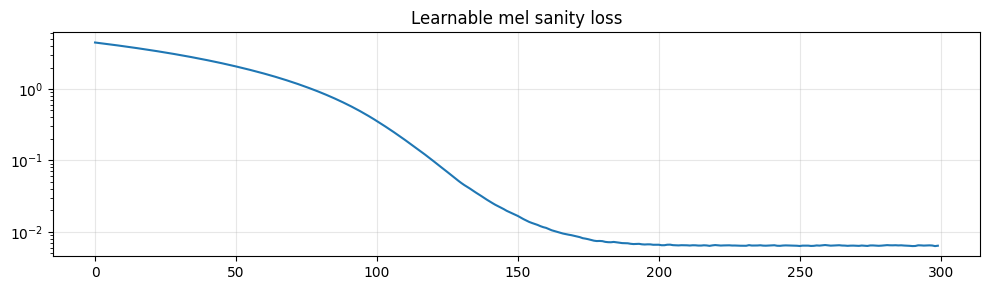

In [112]:
# ===== LEARNABLE MEL SANITY =====
# Test c?c nh?: b? qua encoder/decoder, train tr?c ti?p m?t tensor pred_mel ?? fit GT mel.
# N?u cell n?y nghe ???c c?n overfit model kh?ng nghe ???c, l?i n?m ? encoder/decoder/training model.

import torch
import torchaudio
import matplotlib.pyplot as plt

LEARNABLE_MEL_EPOCHS = 300
LEARNABLE_MEL_LR = 5e-2
LEARNABLE_MEL_MAX_VIDEO_FRAMES = 30
LEARNABLE_MEL_WAV_OUT = 'learnable_mel_sanity.wav'
LEARNABLE_MEL_GT_WAV_OUT = 'learnable_mel_gt.wav'

pt_path, data, video, mel, video_len, mel_len = load_single_pt_for_overfit(
    globals().get('DATA_DIR', 'Processed_Data_Mel_HiFiGAN'),
    pt_path=OVERFIT_PT_PATH,
    max_video_frames=LEARNABLE_MEL_MAX_VIDEO_FRAMES,
)
mel = mel.to(device)
mel_lengths = torch.tensor([mel.shape[1]], device=device, dtype=torch.long)

pred_mel = torch.nn.Parameter(torch.zeros_like(mel))
optimizer = torch.optim.Adam([pred_mel], lr=LEARNABLE_MEL_LR)
criterion_debug = MelReconstructionLoss(lambda_mel=1.0, lambda_delta=0.0, lambda_delta2=0.0, lambda_energy=0.0).to(device)

hist = []
for epoch in range(1, LEARNABLE_MEL_EPOCHS + 1):
    optimizer.zero_grad(set_to_none=True)
    loss = criterion_debug(pred_mel, mel, mel_lengths)
    loss.backward()
    optimizer.step()
    hist.append(float(loss.detach().cpu()))
    if epoch == 1 or epoch % 50 == 0 or epoch == LEARNABLE_MEL_EPOCHS:
        print(f"Epoch {epoch:3d}/{LEARNABLE_MEL_EPOCHS} | Loss={hist[-1]:.6f} | pred min/max={pred_mel.min().item():.3f}/{pred_mel.max().item():.3f}")

with torch.no_grad():
    pred_specs = pred_mel[:1].permute(0, 2, 1).cpu()
    gt_specs = mel[:1].permute(0, 2, 1).cpu()

hifi_gan = load_hifigan(device='cpu')
hop = int(data.get('hop_length', 256))
sr = int(data.get('sample_rate', 16000))
decode_lens = torch.tensor([pred_specs.shape[-1]], dtype=torch.long)
with torch.no_grad():
    pred_wav = hifi_gan.decode_batch(pred_specs, mel_lens=decode_lens, hop_len=hop)
    gt_wav = hifi_gan.decode_batch(gt_specs, mel_lens=decode_lens, hop_len=hop)

torchaudio.save(LEARNABLE_MEL_WAV_OUT, pred_wav.squeeze(1).cpu(), sr)
torchaudio.save(LEARNABLE_MEL_GT_WAV_OUT, gt_wav.squeeze(1).cpu(), sr)
print(f"Saved: {LEARNABLE_MEL_WAV_OUT}")
print(f"Saved: {LEARNABLE_MEL_GT_WAV_OUT}")

plt.figure(figsize=(10, 3))
plt.plot(hist)
plt.yscale('log')
plt.title('Learnable mel sanity loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Overfit target mel recomputed from waveform with SpeechBrain HiFi-GAN mel_spectogram().
Training on: Mưa đá, giông lốc gây thiệt hại tại nhiều địa phương _ VTV24_00002.pt
video=(1, 1, 29, 112, 112), mel=(1, 74, 80), ratio=2.50
target mel stats: min=-9.568, max=0.203, mean=-4.478
----------------------------------------------------------------------
Epoch   1/500 | Loss=4.823053 | MAE=4.4955 | corr=-0.121 | time_std=0.009/0.758 | pred min/max/mean=-2.230/2.231/0.001
Epoch  20/500 | Loss=3.518556 | MAE=3.2588 | corr=-0.016 | time_std=0.139/0.758 | pred min/max/mean=-4.071/1.310/-1.271
Epoch  40/500 | Loss=2.868451 | MAE=2.6354 | corr=-0.021 | time_std=0.244/0.758 | pred min/max/mean=-4.244/0.730/-1.926
Epoch  60/500 | Loss=2.568949 | MAE=2.3455 | corr=0.039 | time_std=0.283/0.758 | pred min/max/mean=-5.224/0.179/-2.276
Epoch  80/500 | Loss=2.428938 | MAE=2.2226 | corr=0.113 | time_std=0.166/0.758 | pred min/max/mean=-5.304/-0.114/-2.389
Epoch 100/500 | Loss=2.240965 | MAE=2.0405 | corr=0

INFO:speechbrain.utils.fetching:Fetch hyperparams.yaml: Using file found at 'c:\Users\Luc\OneDrive\Documents\Nhận dạng\pretrained_models\tts-hifigan-libritts-16kHz\hyperparams.yaml'
INFO:speechbrain.utils.fetching:Fetch generator.ckpt: Using file found at 'c:\Users\Luc\OneDrive\Documents\Nhận dạng\pretrained_models\tts-hifigan-libritts-16kHz\generator.ckpt'


Epoch 500/500 | Loss=0.878260 | MAE=0.6828 | corr=0.804 | time_std=0.298/0.758 | pred min/max/mean=-6.866/-0.652/-4.357


INFO:speechbrain.utils.parameter_transfer:Loading pretrained files for: generator


Decode duration | mel=74 frames | wav?1.184s
----------------------------------------------------------------------
Saved: overfit_pred_mel_hifigan.wav
Saved: overfit_gt_mel_hifigan.wav


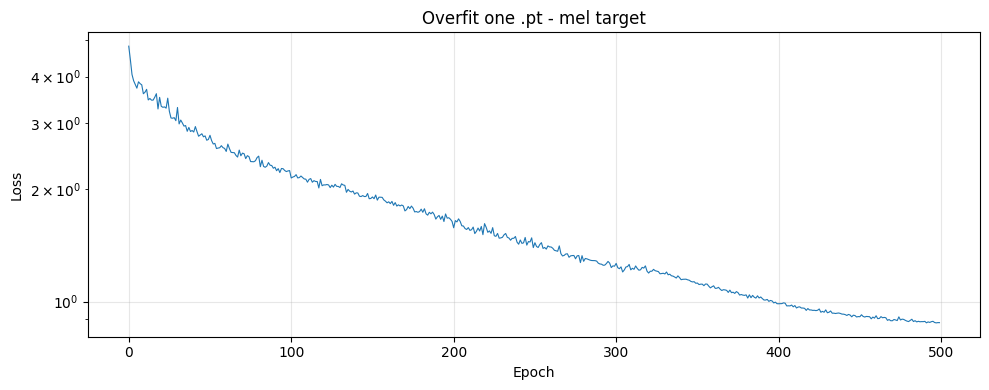

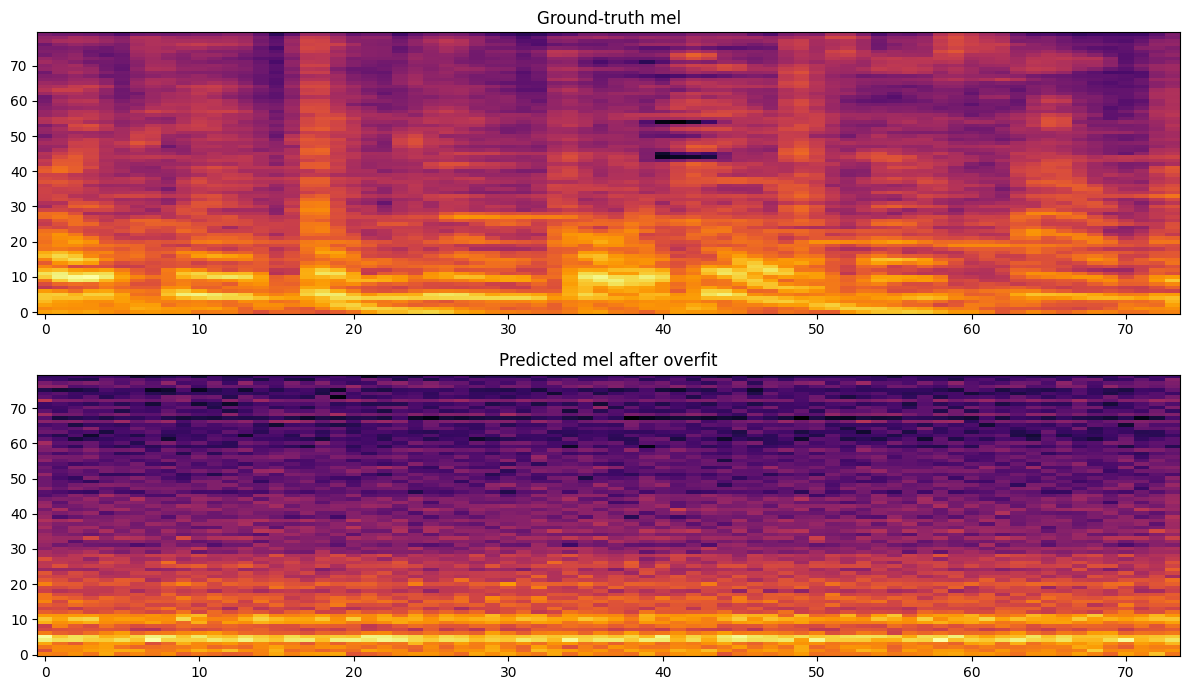

In [114]:
# ===== OVERFIT TEST: train one .pt for 300 epochs, then decode predicted mel with HiFi-GAN =====
# M?c ti?u: ki?m tra model c? th? h?c thu?c 1 sample kh?ng, v? pred_mel -> wav c? nghe ???c kh?ng.

import os
import gc
import torch
import torchaudio
import matplotlib.pyplot as plt
from spikingjelly.activation_based import functional

OVERFIT_PT_PATH = None  # ??t path c? th? n?u mu?n; None = l?y file ??u ti?n trong DATA_DIR
OVERFIT_EPOCHS = 500
OVERFIT_LR = 3e-4
OVERFIT_MAX_VIDEO_FRAMES = 30  # kho?ng 4s ? 25 FPS; gi?m 30/50 n?u OOM ho?c mu?n test nhanh
OVERFIT_WAV_OUT = 'overfit_pred_mel_hifigan.wav'
OVERFIT_GT_WAV_OUT = 'overfit_gt_mel_hifigan.wav'
OVERFIT_RECOMPUTE_MEL_FROM_WAVEFORM = True  # quan tr?ng n?u .pt c? ?ang l?u mel log1p sai scale
# L?u ?: .pt c? log1p s? l?m vocoder r?. H?y migrate mel ho?c rebuild dataset tr??c khi overfit nghi?m t?c.


def load_single_pt_for_overfit(data_dir, pt_path=None, max_video_frames=None):
    pt_path = pick_pt_file(data_dir, pt_path)
    data = torch.load(pt_path, map_location='cpu', weights_only=False)
    video = data['video'].float()
    n_mels = int(data.get('n_mels', 80))
    if video.dim() == 3:
        video = video.unsqueeze(0)

    if OVERFIT_RECOMPUTE_MEL_FROM_WAVEFORM:
        if 'waveform' not in data:
            raise KeyError("OVERFIT_RECOMPUTE_MEL_FROM_WAVEFORM=True nh?ng .pt kh?ng c? key 'waveform'.")
        mel_specs = waveform_to_speechbrain_hifigan_mel(data['waveform'], data)  # (1, 80, T)
        mel = mel_specs.squeeze(0).transpose(0, 1).contiguous().float()          # (T, 80)
        print("Overfit target mel recomputed from waveform with SpeechBrain HiFi-GAN mel_spectogram().")
    else:
        mel = data['mel'].float()
        if mel.dim() == 2 and mel.shape[0] == n_mels and mel.shape[1] != n_mels:
            mel = mel.transpose(0, 1).contiguous()
        if mel.min() >= 0:
            print("WARNING: target mel to?n kh?ng ?m; nhi?u kh? n?ng l? log1p mel sai scale cho HiFi-GAN.")

    video_len = int(data.get('video_len', video.shape[1]))
    mel_len = int(mel.shape[0])
    video = video[:, :video_len]
    mel = mel[:mel_len]

    if max_video_frames is not None and video.shape[1] > max_video_frames:
        sr = int(data.get('sample_rate', 16000))
        fps = float(data.get('fps', 25))
        hop = int(data.get('hop_length', 256))
        ratio = (sr / fps) / hop
        video = video[:, :max_video_frames]
        mel = mel[:int(round(max_video_frames * ratio))]
        video_len = int(video.shape[1])
        mel_len = int(mel.shape[0])

    return pt_path, data, video.unsqueeze(0), mel.unsqueeze(0), video_len, mel_len


def train_single_pt_overfit(pt_path=None, num_epochs=300, lr=1e-4, max_video_frames=100):
    if device.type == 'cuda':
        torch.cuda.empty_cache()
    gc.collect()

    path, data, video, mel, video_len, mel_len = load_single_pt_for_overfit(
        globals().get('DATA_DIR', 'Processed_Data_Mel_HiFiGAN'),
        pt_path=pt_path,
        max_video_frames=max_video_frames,
    )
    video = video.to(device)
    mel = mel.to(device)
    mel_lengths = torch.tensor([mel.shape[1]], device=device, dtype=torch.long)

    local_encoder = SpikingViTEncoder().to(device)
    local_base_decoder = TFiLMSIRENDecoder(hidden_dim=256, out_dim=80, num_layers=4, use_conv=True).to(device)
    local_decoder = MelTemporalUpsampleDecoder(
        local_base_decoder,
        sample_rate=int(data.get('sample_rate', 16000)),
        fps=float(data.get('fps', 25)),
        hop_length=int(data.get('hop_length', 256)),
    ).to(device)

    # Debug phase: start with plain mel L1. Add delta/energy back after single-sample overfit works.
    criterion_local = MelReconstructionLoss(
        lambda_mel=1.0,
        lambda_delta=0.25,
        lambda_delta2=0.05,
        lambda_energy=0.05,
    ).to(device)
    optimizer = torch.optim.Adam(list(local_encoder.parameters()) + list(local_decoder.parameters()), lr=lr)

    print(f"Training on: {os.path.basename(path)}")
    print(f"video={tuple(video.shape)}, mel={tuple(mel.shape)}, ratio={local_decoder.ratio:.2f}")
    print(f"target mel stats: min={mel.min().item():.3f}, max={mel.max().item():.3f}, mean={mel.mean().item():.3f}")
    if mel.min().item() >= 0:
        print("WARNING: target mel kh?ng c? gi? tr? ?m. HiFi-GAN SpeechBrain th??ng c?n compressed log mel c? gi? tr? ?m.")
    print('-' * 70)

    history = []
    local_encoder.train()
    local_decoder.train()
    for epoch in range(1, num_epochs + 1):
        functional.reset_net(local_encoder)
        optimizer.zero_grad(set_to_none=True)

        z = local_encoder(video)
        mel_pred = local_decoder(z, target_len=mel.shape[1])
        loss = criterion_local(mel_pred, mel, mel_lengths)
        if not torch.isfinite(loss):
            raise FloatingPointError(f"Non-finite overfit loss at epoch={epoch}: {float(loss.detach().cpu())}")

        loss.backward()
        torch.nn.utils.clip_grad_norm_(list(local_encoder.parameters()) + list(local_decoder.parameters()), 1.0)
        optimizer.step()
        functional.reset_net(local_encoder)

        history.append(float(loss.detach().cpu()))
        if epoch == 1 or epoch % 20 == 0 or epoch == num_epochs:
            with torch.no_grad():
                mae = (mel_pred.float() - mel.float()).abs().mean().item()
                pred_flat = mel_pred.float().reshape(-1)
                gt_flat = mel.float().reshape(-1)
                corr = torch.nn.functional.cosine_similarity(
                    pred_flat - pred_flat.mean(),
                    gt_flat - gt_flat.mean(),
                    dim=0,
                ).item()
                time_std = mel_pred.float().std(dim=1).mean().item()
                gt_time_std = mel.float().std(dim=1).mean().item()
                print(
                    f"Epoch {epoch:3d}/{num_epochs} | Loss={history[-1]:.6f} | MAE={mae:.4f} | corr={corr:.3f} | "
                    f"time_std={time_std:.3f}/{gt_time_std:.3f} | "
                    f"pred min/max/mean={mel_pred.min().item():.3f}/{mel_pred.max().item():.3f}/{mel_pred.mean().item():.3f}"
                )

        del z, mel_pred, loss
        if device.type == 'cuda':
            torch.cuda.empty_cache()

    local_encoder.eval()
    local_decoder.eval()
    with torch.no_grad():
        functional.reset_net(local_encoder)
        mel_pred = local_decoder(local_encoder(video), target_len=mel.shape[1])
        pred_specs = mel_pred[:1, :mel.shape[1]].permute(0, 2, 1).cpu()
        gt_specs = mel[:1].permute(0, 2, 1).cpu()

    hifi_gan = load_hifigan(device='cpu')
    with torch.no_grad():
        decode_lens = torch.tensor([pred_specs.shape[-1]], dtype=torch.long)
        hop = int(data.get('hop_length', 256))
        pred_wav = hifi_gan.decode_batch(pred_specs, mel_lens=decode_lens, hop_len=hop)
        gt_wav = hifi_gan.decode_batch(gt_specs, mel_lens=decode_lens, hop_len=hop)

    sr = int(data.get('sample_rate', 16000))
    print(f"Decode duration | mel={pred_specs.shape[-1]} frames | wav?{pred_specs.shape[-1] * int(data.get('hop_length', 256)) / sr:.3f}s")
    torchaudio.save(OVERFIT_WAV_OUT, pred_wav.squeeze(1).cpu(), sr)
    torchaudio.save(OVERFIT_GT_WAV_OUT, gt_wav.squeeze(1).cpu(), sr)
    print('-' * 70)
    print(f"Saved: {OVERFIT_WAV_OUT}")
    print(f"Saved: {OVERFIT_GT_WAV_OUT}")

    plt.figure(figsize=(10, 4))
    plt.plot(history, linewidth=0.8)
    plt.yscale('log')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Overfit one .pt - mel target')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(2, 1, figsize=(12, 7))
    axes[0].imshow(gt_specs[0].numpy(), aspect='auto', origin='lower', cmap='inferno')
    axes[0].set_title('Ground-truth mel')
    axes[1].imshow(pred_specs[0].numpy(), aspect='auto', origin='lower', cmap='inferno')
    axes[1].set_title('Predicted mel after overfit')
    plt.tight_layout()
    plt.show()

    return history, local_encoder, local_decoder

history, overfit_encoder, overfit_decoder = train_single_pt_overfit(
    pt_path=OVERFIT_PT_PATH,
    num_epochs=OVERFIT_EPOCHS,
    lr=OVERFIT_LR,
    max_video_frames=OVERFIT_MAX_VIDEO_FRAMES,
)


## Predict vs ground truth

In [ ]:
from spikingjelly.activation_based import functional

encoder.eval()
decoder.eval()
with torch.no_grad():
    batch = next(iter(dataloader))
    v, m, video_lens, mel_lens = batch[:4]
    v = v.to(device)
    functional.reset_net(encoder)
    mel_pred = decoder(encoder(v), target_len=m.shape[1])
    real_len = int(mel_lens[0].item())
    mel_pred_sample = mel_pred[0, :real_len, :].cpu().numpy().T
    mel_gt_sample = m[0, :real_len, :].cpu().numpy().T

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
ax1.imshow(mel_gt_sample, aspect='auto', origin='lower', cmap='inferno')
ax1.set_title("Ground Truth Mel")
ax2.imshow(mel_pred_sample, aspect='auto', origin='lower', cmap='inferno')
ax2.set_title("Predicted Mel")
plt.tight_layout()
plt.show()


# New approach: TFiLM WIRE DECODER

## FiLM + WIRE

In [ ]:
class FiLMWIRE(nn.Module):
    def __init__(self, in_features, out_features, omega_zero=30.0, scale=1.0, is_first=False):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)
        self.omega_zero = omega_zero
        self.scale = scale
        self.is_first = is_first
        with torch.no_grad():
            if self.is_first:
                bound = 1 / in_features
            else:
                bound = torch.sqrt(torch.tensor(6.0 / in_features)) / self.omega_zero
            self.linear.weight.uniform_(-bound, bound)

    def forward(self, X, gamma, beta):
        X = self.linear(X)
        if not self.is_first:
            X = self.omega_zero * X 
        modulated = gamma * X + beta
        real = torch.cos(self.omega_zero * modulated) * torch.exp(-modulated**2 / (2 * self.scale**2))
        return real


## FiLM WIRE DECODER

In [ ]:
class TFiLMWIREDecoder(nn.Module):
    def __init__(self, condition_dim=512, hidden_dim=256, out_dim=80, num_layers=4, omega_zero=30.0, scale=5.0, use_conv=False):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

        total_params = num_layers * 2 * hidden_dim
        if use_conv:
            self.param_net = nn.Conv1d(condition_dim, total_params, kernel_size=3, padding=1)
            nn.init.zeros_(self.param_net.weight)
            with torch.no_grad():
                for i in range(num_layers):
                    start = i * 2 * hidden_dim
                    self.param_net.bias[start:start + hidden_dim].fill_(0.0)
                    self.param_net.bias[start + hidden_dim:start + 2 * hidden_dim].fill_(1.0)
        else:
            self.param_net = nn.Sequential(
                nn.Linear(condition_dim, condition_dim),
                nn.ReLU(),
                nn.Linear(condition_dim, total_params)
            )
            nn.init.zeros_(self.param_net[-1].weight)
            with torch.no_grad():
                for i in range(num_layers):
                    start = i * 2  * hidden_dim
                    self.param_net[-1].bias[start:start + hidden_dim].fill_(0.0)
                    self.param_net[-1].bias[start + hidden_dim:start + 2 * hidden_dim].fill_(1.0)

        self.wire_layers = nn.ModuleList()
        self.wire_layers.append(FiLMWIRE(in_features=hidden_dim, out_features=hidden_dim, omega_zero=omega_zero, scale=scale, is_first=True))
        for _ in range(1, num_layers):
            self.wire_layers.append(FiLMWIRE(in_features=hidden_dim, out_features=hidden_dim, omega_zero=omega_zero, scale=scale, is_first=False))
        self.final_layer = nn.Linear(hidden_dim , out_dim)
        nn.init.xavier_uniform_(self.final_layer.weight)
        nn.init.zeros_(self.final_layer.bias)

        self.input_constant = nn.Parameter(torch.randn(1, hidden_dim) * 0.1)
    
    def forward(self, Condition):
        B, T, _ = Condition.shape
        if isinstance(self.param_net, nn.Conv1d):
            params = self.param_net(Condition.permute(0, 2, 1))
            params = params.permute(0, 2, 1)
        else:
            params = self.param_net(Condition.reshape(B * T, -1))
            params = params.reshape(B, T, -1)
        
        gammas = []
        betas = []

        for i in range(self.num_layers):
            start = i * 2 * self.hidden_dim
            beta = params[:, :, start: start + self.hidden_dim]
            gamma = params[:, :, start + self.hidden_dim: start + 2 * self.hidden_dim]
            gammas.append(gamma)
            betas.append(beta)
        
        X = self.input_constant.expand(B * T, -1) # B*T, hidden_dim
        gammas_flat = [g.reshape(B * T, -1) for g in gammas]
        betas_flat = [b.reshape(B * T, -1) for b in betas]

        for i, layer in enumerate(self.wire_layers):
            X = layer(X, gammas_flat[i], betas_flat[i])
        out = self.final_layer(X)
        out = out.reshape(B, T, -1)
        return out

# New approach: WIRE + SIREN DUAL DECODER

## Dual Layer

In [ ]:
class DualFiLMLayer(nn.Module):
    def __init__(self, in_features, out_features, omega_siren=30.0, omega_wire=30.0, scale=5.0, is_first=False):
        super().__init__()
        self.siren = FiLMSIREN(in_features, out_features, omega_siren, is_first)
        self.wire = FiLMWIRE(in_features, out_features, omega_wire, is_first)
        self.fusion = nn.Sequential(
            nn.Linear(out_features * 2, out_features),
            nn.ReLU(),
            nn.Linear(out_features, out_features)
        )

    def forward(self, X, gamma_s, beta_s, gamma_w, beta_w):
        out_siren = self.siren(X, gamma_s, beta_s)
        out_wire = self.wire(X, gamma_w, beta_w)
        out = torch.cat([out_siren, out_wire], dim=-1)
        out = self.fusion(out)
        return out

## Dual Decoder

In [ ]:
class DualDecoder(nn.Module):
    def __init__(self, condition_dim=512, hidden_dim=256, out_dim=80, num_layers=4, omega_siren=30.0, omega_wire=30.0, scale=5.0, use_conv=False):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

        total_params = self.num_layers * 4 * hidden_dim
        if use_conv:
            self.param_net = nn.Conv1d(condition_dim, total_params, kernel_size=3, padding=1)
            nn.init.zeros_(self.param_net.weight)
            with torch.no_grad():
                for i in range(num_layers):
                    start = i * 4 * hidden_dim
                    self.param_net.bias[start: start + hidden_dim].fill_(0.0)
                    self.param_net.bias[start + hidden_dim: start + 2 * hidden_dim].fill_(1.0)
                    self.param_net.bias[start + 2 * hidden_dim: start + 3 * hidden_dim].fill_(0.0)
                    self.param_net.bias[start + 3 * hidden_dim: start + 4 * hidden_dim].fill_(1.0) 

        else: 
            self.param_net = nn.Sequential(
                nn.Linear(condition_dim, condition_dim),
                nn.ReLU(),
                nn.Linear(condition_dim, total_params)
            )
            nn.init.zeros_(self.param_net[-1].weight)
            with torch.no_grad():
                for i in range(num_layers):
                    start = i * 4 * hidden_dim
                    self.param_net[-1].bias[start: start + hidden_dim].fill_(0.0)
                    self.param_net[-1].bias[start + hidden_dim: start + 2 * hidden_dim].fill_(1.0)
                    self.param_net[-1].bias[start + 2 * hidden_dim: start + 3 * hidden_dim].fill_(0.0)
                    self.param_net[-1].bias[start + 3 * hidden_dim: start + 4 * hidden_dim].fill_(1.0)

        self.dual_layers = nn.ModuleList()
        self.dual_layers.append(DualFiLMLayer(hidden_dim, hidden_dim, omega_siren, omega_wire, scale, is_first=True))
        for _ in range(1, num_layers):
            self.dual_layers.append(DualFiLMLayer(hidden_dim, hidden_dim, omega_siren, omega_wire, scale, is_first=False))
        self.final_layer = nn.Linear(hidden_dim, out_dim)
        nn.init.xavier_uniform_(self.final_layer.weight)
        nn.init.zeros_(self.final_layer.bias)

        self.input_constant = nn.Parameter(torch.randn(1, hidden_dim) * 0.1)

    def forward(self, Condition):
        B, T, _ = Condition.shape
        if isinstance(self.param_net, nn.Conv1d):
            params = self.param_net(Condition.permute(0, 2, 1))
            params = params.permute(0, 2, 1)
        else:
            params = self.param_net(Condition.reshape(B * T, -1))
            params = params.reshape(B, T, -1)

        gammas_s = []
        betas_s = []
        gammas_w = []
        betas_w = []

        for i in range(self.num_layers):
            start = i * 4 * self.hidden_dim
            # SIREN
            beta_s = params[:, :, start: start + self.hidden_dim]
            gamma_s = params[:, :, start + self.hidden_dim: start + 2 * self.hidden_dim]

            # WIRE
            beta_w = params[:, :, start + 2 * self.hidden_dim: start + 3 * self.hidden_dim]
            gamma_w = params[:, :, start + 3 * self.hidden_dim: start + 4 * self.hidden_dim]

            gammas_s.append(gamma_s)
            betas_s.append(beta_s)
            gammas_w.append(gamma_w)
            betas_w.append(beta_w)

        X = self.input_constant.expand(B * T, -1)
        
        gammas_s_flat = [g.reshape(B * T, -1) for g in gammas_s]
        betas_s_flat = [b.reshape(B * T, -1) for b in betas_s]
        gammas_w_flat = [g.reshape(B * T, -1) for g in gammas_w]
        betas_w_flat = [b.reshape(B * T, -1) for b in betas_w]

        for i, layer in enumerate(self.dual_layers):
            X = layer(
                X,
                gammas_s_flat[i], betas_s_flat[i],
                gammas_w_flat[i], betas_w_flat[i]
            )
        out = self.final_layer(X)
        out = out.reshape(B, T, -1)
        return out
            


# New approach: TFiLM FINER DECODER

## TFiLM FINER Layer

In [ ]:
class FiLMFINER(nn.Module):
    def __init__(self, in_features, out_features, omega_zero=30.0, is_first=False):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)
        self.omega_zero = omega_zero
        self.is_first = is_first
        with torch.no_grad():
            if self.is_first:
                bound = 1 / in_features
            else:
                bound = torch.sqrt(torch.tensor(6.0 / in_features)) / self.omega_zero
            self.linear.weight.uniform_(-bound, bound)
        
    def forward(self, gamma, beta):
        X = self.linear(X)
        if not self.is_first:
            X = self.omega_zero * X
        modulated = gamma * X + beta
        return torch.sin(self.omega_zero * (torch.abs(modulated) + 1.0) * modulated)

## TFiLM FINER DECODER

In [ ]:
class TFiLMFINERDecoder(nn.Module):
    def __init__(self, condition_dim=512, hidden_dim=256, out_dim=80, num_layers=4, omega_zero=30.0, use_conv=False):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

        total_params = num_layers * 2 * hidden_dim
        if use_conv:
            self.param_net = nn.Conv1d(condition_dim, total_params, kernel_size=3, padding=1)
            nn.init.zeros_(self.param_net.weight)
            with torch.no_grad():
                for i in range(num_layers):
                    start = i * 2 * hidden_dim
                    self.param_net.bias[start:start + hidden_dim].fill_(0.0)
                    self.param_net.bias[start + hidden_dim:start + 2 * hidden_dim].fill_(1.0)
        else:
            self.param_net = nn.Sequential(
                nn.Linear(condition_dim, condition_dim),
                nn.ReLU(),
                nn.Linear(condition_dim, total_params)
            )
            nn.init.zeros_(self.param_net[-1].weight)
            with torch.no_grad():
                for i in range(num_layers):
                    start = i * 2  * hidden_dim
                    self.param_net[-1].bias[start:start + hidden_dim].fill_(0.0)
                    self.param_net[-1].bias[start + hidden_dim:start + 2 * hidden_dim].fill_(1.0)

        self.finer_layers = nn.ModuleList()
        self.finer_layers.append(FiLMFINER(in_features=hidden_dim, out_features=hidden_dim, omega_zero=omega_zero, is_first=True))
        for _ in range(1, num_layers):
            self.finer_layers.append(FiLMFINER(in_features=hidden_dim, out_features=hidden_dim, omega_zero=omega_zero, is_first=False))
        self.final_layer = nn.Linear(hidden_dim , out_dim)
        nn.init.xavier_uniform_(self.final_layer.weight)
        nn.init.zeros_(self.final_layer.bias)

        self.input_constant = nn.Parameter(torch.randn(1, hidden_dim) * 0.1)
    
    def forward(self, Condition):
        B, T, _ = Condition.shape
        if isinstance(self.param_net, nn.Conv1d):
            params = self.param_net(Condition.permute(0, 2, 1))
            params = params.permute(0, 2, 1)
        else:
            params = self.param_net(Condition.reshape(B * T, -1))
            params = params.reshape(B, T, -1)
        
        gammas = []
        betas = []

        for i in range(self.num_layers):
            start = i * 2 * self.hidden_dim
            beta = params[:, :, start: start + self.hidden_dim]
            gamma = params[:, :, start + self.hidden_dim: start + 2 * self.hidden_dim]
            gammas.append(gamma)
            betas.append(beta)
        
        X = self.input_constant.expand(B * T, -1) # B*T, hidden_dim
        gammas_flat = [g.reshape(B * T, -1) for g in gammas]
        betas_flat = [b.reshape(B * T, -1) for b in betas]

        for i, layer in enumerate(self.finer_layers):
            X = layer(X, gammas_flat[i], betas_flat[i])
        out = self.final_layer(X)
        out = out.reshape(B, T, -1)
        return out

# New approach: Wrap FINER SIREN DECODER

## FINER SIREN WRAP

In [ ]:
# out = sin((∣b~∣+1)⋅(ω0(Wx+b)))
class FiLMWrapFINSIREN(nn.Module):
    def __init__(self, in_features, out_features, omega_zero=30.0, is_first=False):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features, bias=True)
        self.omega_zero = omega_zero
        self.is_first = is_first
        self.freq_bias = nn.Parameter(torch.empty(out_features))
        self.reset_parameters()
    
    def reset_parameters(self):
        with torch.no_grad():
            if self.is_first:
                bound = 1.0 / self.linear.in_features
            else:
                bound = torch.sqrt(torch.tensor(6.0 / self.linear.in_features)) / self.omega_zero
            self.linear.weight.uniform_(-bound, bound)
            nn.init.zeros_(self.linear.bias)
            nn.init.uniform_(self.freq_bias, -10.0, 10.0)
    
    def forward(self, X, gamma, beta):
        X = self.linear(X)
        if not self.is_first:
            X = self.omega_zero * X
        modulated = gamma * X + beta
        scaled = torch.abs(self.freq_bias) + 1.0
        out = torch.sin(scaled.unsqueeze(0) * modulated)
        return out

## TFiLM WRAP FIN SIN

In [ ]:
class TFiLMWrapFISINDecoder(nn.Module):
    def __init__(self, condition_dim=512, hidden_dim=256, out_dim=80, num_layers=4, omega_zero=30.0, use_conv=False):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

        total_params = num_layers * 2 * hidden_dim
        if use_conv:
            self.param_net = nn.Conv1d(condition_dim, total_params, kernel_size=3, padding=1)
            nn.init.zeros_(self.param_net.weight)
            with torch.no_grad():
                for i in range(num_layers):
                    start = i * 2 * hidden_dim
                    self.param_net.bias[start:start + hidden_dim].fill_(0.0)
                    self.param_net.bias[start + hidden_dim:start + 2 * hidden_dim].fill_(1.0)
        else:
            self.param_net = nn.Sequential(
                nn.Linear(condition_dim, condition_dim),
                nn.ReLU(),
                nn.Linear(condition_dim, total_params)
            )
            nn.init.zeros_(self.param_net[-1].weight)
            with torch.no_grad():
                for i in range(num_layers):
                    start = i * 2  * hidden_dim
                    self.param_net[-1].bias[start:start + hidden_dim].fill_(0.0)
                    self.param_net[-1].bias[start + hidden_dim:start + 2 * hidden_dim].fill_(1.0)

        self.wrap_layers = nn.ModuleList()
        self.wrap_layers.append(FiLMWrapFINSIREN(in_features=hidden_dim, out_features=hidden_dim, omega_zero=omega_zero, is_first=True))
        for _ in range(1, num_layers):
            self.wrap_layers.append(FiLMWrapFINSIREN(in_features=hidden_dim, out_features=hidden_dim, omega_zero=omega_zero, is_first=False))
        self.final_layer = nn.Linear(hidden_dim , out_dim)
        nn.init.xavier_uniform_(self.final_layer.weight)
        nn.init.zeros_(self.final_layer.bias)

        self.input_constant = nn.Parameter(torch.randn(1, hidden_dim) * 0.1)
    
    def forward(self, Condition):
        B, T, _ = Condition.shape
        if isinstance(self.param_net, nn.Conv1d):
            params = self.param_net(Condition.permute(0, 2, 1))
            params = params.permute(0, 2, 1)
        else:
            params = self.param_net(Condition.reshape(B * T, -1))
            params = params.reshape(B, T, -1)
        
        gammas = []
        betas = []

        for i in range(self.num_layers):
            start = i * 2 * self.hidden_dim
            beta = params[:, :, start: start + self.hidden_dim]
            gamma = params[:, :, start + self.hidden_dim: start + 2 * self.hidden_dim]
            gammas.append(gamma)
            betas.append(beta)
        
        X = self.input_constant.expand(B * T, -1) # B*T, hidden_dim
        gammas_flat = [g.reshape(B * T, -1) for g in gammas]
        betas_flat = [b.reshape(B * T, -1) for b in betas]

        for i, layer in enumerate(self.wrap_layers):
            X = layer(X, gammas_flat[i], betas_flat[i])
        out = self.final_layer(X)
        out = out.reshape(B, T, -1)
        return out

# New approach: Wrap FINER WIRE DECODER

## FINER WIRE WRAP

In [ ]:
class FiLMWrapFINWIRE(nn.Module):
    def __init__(self, in_features, out_features, omega_zero=30.0, scale=5.0, is_first=False):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)
        self.omega_zero = omega_zero
        self.scale = scale
        self.is_first = is_first
        self.freq_bias = nn.Parameter(torch.empty(out_features))
        with torch.no_grad():
            if self.is_first:
                bound = 1 / self.linear.in_features
            else:
                bound = torch.sqrt(torch.tensor(6.0 / in_features)) / self.omega_zero
            self.linear.weight.uniform_(-bound, bound)
            nn.init.zeros_(self.linear.bias)
            nn.init.uniform_(self.freq_bias, -10, 10)

    def forward(self, X, gamma, beta):
        X = self.linear(X)
        if not self.is_first:
            X = self.omega_zero * X 
        modulated = gamma * X + beta
        scaled = torch.abs(self.freq_bias) + 1.0
        real = torch.cos(scaled.unsqueeze(0) * modulated) * torch.exp(-modulated**2 / (2 * self.scale**2))
        return real


## TFiLM WRAP FIN WI DEOCDER

In [ ]:
class TFiLMWrapFIWIDecoder(nn.Module):
    def __init__(self, condition_dim=512, hidden_dim=256, out_dim=80, num_layers=4, omega_zero=30.0, scale=5.0, use_conv=False):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

        total_params = num_layers * 2 * hidden_dim
        if use_conv:
            self.param_net = nn.Conv1d(condition_dim, total_params, kernel_size=3, padding=1)
            nn.init.zeros_(self.param_net.weight)
            with torch.no_grad():
                for i in range(num_layers):
                    start = i * 2 * hidden_dim
                    self.param_net.bias[start:start + hidden_dim].fill_(0.0)
                    self.param_net.bias[start + hidden_dim:start + 2 * hidden_dim].fill_(1.0)
        else:
            self.param_net = nn.Sequential(
                nn.Linear(condition_dim, condition_dim),
                nn.ReLU(),
                nn.Linear(condition_dim, total_params)
            )
            nn.init.zeros_(self.param_net[-1].weight)
            with torch.no_grad():
                for i in range(num_layers):
                    start = i * 2  * hidden_dim
                    self.param_net[-1].bias[start:start + hidden_dim].fill_(0.0)
                    self.param_net[-1].bias[start + hidden_dim:start + 2 * hidden_dim].fill_(1.0)

        self.wrap_layers = nn.ModuleList()
        self.wrap_layers.append(FiLMWrapFINWIRE(in_features=hidden_dim, out_features=hidden_dim, omega_zero=omega_zero, scale=scale, is_first=True))
        for _ in range(1, num_layers):
            self.wrap_layers.append(FiLMWrapFINWIRE(in_features=hidden_dim, out_features=hidden_dim, omega_zero=omega_zero, scale=scale, is_first=False))
        self.final_layer = nn.Linear(hidden_dim , out_dim)
        nn.init.xavier_uniform_(self.final_layer.weight)
        nn.init.zeros_(self.final_layer.bias)

        self.input_constant = nn.Parameter(torch.randn(1, hidden_dim) * 0.1)
    
    def forward(self, Condition):
        B, T, _ = Condition.shape
        if isinstance(self.param_net, nn.Conv1d):
            params = self.param_net(Condition.permute(0, 2, 1))
            params = params.permute(0, 2, 1)
        else:
            params = self.param_net(Condition.reshape(B * T, -1))
            params = params.reshape(B, T, -1)
        
        gammas = []
        betas = []

        for i in range(self.num_layers):
            start = i * 2 * self.hidden_dim
            beta = params[:, :, start: start + self.hidden_dim]
            gamma = params[:, :, start + self.hidden_dim: start + 2 * self.hidden_dim]
            gammas.append(gamma)
            betas.append(beta)
        
        X = self.input_constant.expand(B * T, -1) # B*T, hidden_dim
        gammas_flat = [g.reshape(B * T, -1) for g in gammas]
        betas_flat = [b.reshape(B * T, -1) for b in betas]

        for i, layer in enumerate(self.wrap_layers):
            X = layer(X, gammas_flat[i], betas_flat[i])
        out = self.final_layer(X)
        out = out.reshape(B, T, -1)
        return out

# New approach: Dual Wrap FINER - SIREN WIRE

## Dual Wrap Layer

In [ ]:
class DualWrapLayer(nn.Module):
    def __init__(self, in_features, out_features, omega_fisin=30.0, omega_fiwi=30.0, scale=5.0, is_first=False):
        super().__init__()
        self.fisin = FiLMWrapFINSIREN(in_features, out_features, omega_fisin, is_first)
        self.fiwi = FiLMWrapFINWIRE(in_features, out_features, omega_fiwi, scale, is_first)
        self.fusion = nn.Sequential(
            nn.Linear(out_features * 2, out_features),
            nn.ReLU(),
            nn.Linear(out_features, out_features)
        )
    
    def forward(self, X, gamma_fs, beta_fs, gamma_fw, beta_fw):
        out_fs = self.fisin(X, gamma_fs, beta_fs)
        out_fw = self.fiwi(X, gamma_fw, beta_fw)
        out = torch.cat([out_fs, out_fw], dim=-1)
        out = self.fusion(out)
        return out

## Dual Wrap Decoder

In [ ]:
class DualWrapDecoder(nn.Module):
    def __init__(self, condition_dim=512, hidden_dim=256, out_dim=80, num_layers=4, omega_siren=30.0, omega_wire=30.0, scale=5.0, use_conv=False):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

        total_params = self.num_layers * 4 * hidden_dim
        if use_conv:
            self.param_net = nn.Conv1d(condition_dim, total_params, kernel_size=3, padding=1)
            nn.init.zeros_(self.param_net.weight)
            with torch.no_grad():
                for i in range(num_layers):
                    start = i * 4 * hidden_dim
                    self.param_net.bias[start: start + hidden_dim].fill_(0.0)
                    self.param_net.bias[start + hidden_dim: start + 2 * hidden_dim].fill_(1.0)
                    self.param_net.bias[start + 2 * hidden_dim: start + 3 * hidden_dim].fill_(0.0)
                    self.param_net.bias[start + 3 * hidden_dim: start + 4 * hidden_dim].fill_(1.0) 

        else: 
            self.param_net = nn.Sequential(
                nn.Linear(condition_dim, condition_dim),
                nn.ReLU(),
                nn.Linear(condition_dim, total_params)
            )
            nn.init.zeros_(self.param_net[-1].weight)
            with torch.no_grad():
                for i in range(num_layers):
                    start = i * 4 * hidden_dim
                    self.param_net[-1].bias[start: start + hidden_dim].fill_(0.0)
                    self.param_net[-1].bias[start + hidden_dim: start + 2 * hidden_dim].fill_(1.0)
                    self.param_net[-1].bias[start + 2 * hidden_dim: start + 3 * hidden_dim].fill_(0.0)
                    self.param_net[-1].bias[start + 3 * hidden_dim: start + 4 * hidden_dim].fill_(1.0)

        self.dual_layers = nn.ModuleList()
        self.dual_layers.append(DualWrapLayer(hidden_dim, hidden_dim, omega_siren, omega_wire, scale, is_first=True))
        for _ in range(1, num_layers):
            self.dual_layers.append(DualWrapLayer(hidden_dim, hidden_dim, omega_siren, omega_wire, scale, is_first=False))
        self.final_layer = nn.Linear(hidden_dim, out_dim)
        nn.init.xavier_uniform_(self.final_layer.weight)
        nn.init.zeros_(self.final_layer.bias)

        self.input_constant = nn.Parameter(torch.randn(1, hidden_dim) * 0.1)

    def forward(self, Condition):
        B, T, _ = Condition.shape
        if isinstance(self.param_net, nn.Conv1d):
            params = self.param_net(Condition.permute(0, 2, 1))
            params = params.permute(0, 2, 1)
        else:
            params = self.param_net(Condition.reshape(B * T, -1))
            params = params.reshape(B, T, -1)

        gammas_s = []
        betas_s = []
        gammas_w = []
        betas_w = []

        for i in range(self.num_layers):
            start = i * 4 * self.hidden_dim
            # SIREN
            beta_s = params[:, :, start: start + self.hidden_dim]
            gamma_s = params[:, :, start + self.hidden_dim: start + 2 * self.hidden_dim]

            # WIRE
            beta_w = params[:, :, start + 2 * self.hidden_dim: start + 3 * self.hidden_dim]
            gamma_w = params[:, :, start + 3 * self.hidden_dim: start + 4 * self.hidden_dim]

            gammas_s.append(gamma_s)
            betas_s.append(beta_s)
            gammas_w.append(gamma_w)
            betas_w.append(beta_w)

        X = self.input_constant.expand(B * T, -1)
        gammas_s_flat = [g.reshape(B * T, -1) for g in gammas_s]
        betas_s_flat = [b.reshape(B * T, -1) for b in betas_s]
        gammas_w_flat = [g.reshape(B * T, -1) for g in gammas_w]
        betas_w_flat = [b.reshape(B * T, -1) for b in betas_w]

        for i, layer in enumerate(self.dual_layers):
            X = layer(
                X,
                gammas_s_flat[i], betas_s_flat[i],
                gammas_w_flat[i], betas_w_flat[i]
            )
        out = self.final_layer(X)
        out = out.reshape(B, T, -1)
        return out
            
